## 1. Transfer Data Preparation

In [2]:
import pandas as pd
import numpy as np

# Load summer transfer data
transfer_path = "EPL_summer_transfers_2014_2025.xlsx"
transfer_df = pd.read_excel(transfer_path, sheet_name="Sheet1")

transfer_df.head()

,Season,Team,Summer_Expenditure_EUR_m,Summer_Income_EUR_m,Transfer_Balance_EUR_m,Source_URL,Net_Spend_EUR_m,Log_Expenditure,Expenditure_z
0,2014-15,Arsenal FC,101.73,25.20,-76.53,https://www.transfermarkt.com/premier-league/t...,76.53,4.632104,1.055854
1,2014-15,Aston Villa,9.25,1.25,-8.00,https://www.transfermarkt.com/premier-league/t...,8.00,2.327278,-1.234372
2,2014-15,Burnley FC,10.06,0.00,-10.06,https://www.transfermarkt.com/premier-league/t...,10.06,2.403335,-1.158797
3,2014-15,Chelsea FC,106.70,96.51,-10.19,https://www.transfermarkt.com/premier-league/t...,10.19,4.679350,1.102800
4,2014-15,Crystal Palace,15.74,1.80,-13.94,https://www.transfermarkt.com/premier-league/t...,13.94,2.817801,-0.746956


In [3]:
# Total transfer activity:
# expenditure + income measures the overall scale of squad turnover
transfer_df["Transfer_Activity"] = (
    transfer_df["Summer_Expenditure_EUR_m"]
    + transfer_df["Summer_Income_EUR_m"]
)

# Log transformation to reduce the influence of extremely large transfer windows
transfer_df["Log_Transfer_Activity"] = np.log1p(
    transfer_df["Transfer_Activity"]
)

In [4]:
transfer_df[
    [
        "Season",
        "Team",
        "Summer_Expenditure_EUR_m",
        "Summer_Income_EUR_m",
        "Transfer_Activity",
        "Log_Transfer_Activity"
    ]
].head(20)

,Season,Team,Summer_Expenditure_EUR_m,Summer_Income_EUR_m,Transfer_Activity,Log_Transfer_Activity
0,2014-15,Arsenal FC,101.73,25.20,126.93,4.851483
1,2014-15,Aston Villa,9.25,1.25,10.50,2.442347
2,2014-15,Burnley FC,10.06,0.00,10.06,2.403335
3,2014-15,Chelsea FC,106.70,96.51,203.21,5.319149
4,2014-15,Crystal Palace,15.74,1.80,17.54,2.919931
5,2014-15,Everton FC,40.16,1.90,42.06,3.762594
6,2014-15,Hull City,44.26,18.70,62.96,4.158258
7,2014-15,Leicester City,13.86,0.00,13.86,2.698673
8,2014-15,Liverpool FC,151.43,91.97,243.40,5.498806
9,2014-15,Manchester City,70.50,30.30,100.80,4.623010


In [5]:
transfer_df["Transfer_Activity_z"] = (
    transfer_df
    .groupby("Season")["Log_Transfer_Activity"]
    .transform(lambda x: (x - x.mean()) / x.std())
)

In [6]:
transfer_df[
    transfer_df["Season"] == "2022-23"
][
    [
        "Team",
        "Transfer_Activity",
        "Log_Transfer_Activity",
        "Transfer_Activity_z"
    ]
].sort_values(
    "Transfer_Activity_z",
    ascending=False
)

,Team,Transfer_Activity,Log_Transfer_Activity,Transfer_Activity_z
165,Chelsea FC,357.31,5.881399,1.459422
172,Manchester City,303.97,5.720213,1.214263
173,Manchester United,263.32,5.577160,0.996682
169,Leeds United,223.14,5.412271,0.745888
177,Tottenham Hotspur,212.45,5.363403,0.671560
178,West Ham United,202.40,5.315174,0.598206
179,Wolverhampton Wanderers,200.10,5.303802,0.580909
171,Liverpool FC,179.00,5.192957,0.412315
175,Nottingham Forest,170.05,5.141956,0.334744
164,Brighton & Hove Albion,160.10,5.082025,0.243590


In [7]:
# Keep only transfer windows used in the Bayesian transition model
model_seasons = [
    "2022-23",
    "2023-24",
    "2024-25",
    "2025-26"
]

transfer_model = transfer_df[
    transfer_df["Season"].isin(model_seasons)
].copy()

print(transfer_model["Season"].value_counts().sort_index())
print("Shape:", transfer_model.shape)

Season
2022-23    20
2023-24    20
2024-25    20
2025-26    20
Name: count, dtype: int64
Shape: (80, 12)


In [8]:
strength_df = pd.read_excel(
    "unified_strength_index.xlsx"
)

strength_df.head()

,Season,Team,S
0,2021-22,Arsenal,0.435698
1,2021-22,Aston Villa,0.467211
2,2021-22,Brentford,-0.455542
3,2021-22,Brighton,-0.107825
4,2021-22,Burnley,-1.278786


In [9]:
print(strength_df.shape)
print(strength_df["Season"].value_counts().sort_index())
print(strength_df.columns)

(100, 3)
Season
2021-22    20
2022-23    20
2023-24    20
2024-25    20
2025-26    20
Name: count, dtype: int64
Index(['Season', 'Team', 'S'], dtype='object')


In [10]:
# Check whether team names are consistent between the two datasets

transfer_teams = set(transfer_model["Team"].unique())
strength_teams = set(strength_df["Team"].unique())

only_in_transfer = sorted(transfer_teams - strength_teams)
only_in_strength = sorted(strength_teams - transfer_teams)

print("Only in transfer data:")
print(only_in_transfer)

print("\nOnly in strength data:")
print(only_in_strength)

Only in transfer data:
['AFC Bournemouth', 'Arsenal FC', 'Brentford FC', 'Brighton & Hove Albion', 'Burnley FC', 'Chelsea FC', 'Everton FC', 'Fulham FC', 'Ipswich Town', 'Leeds United', 'Leicester City', 'Liverpool FC', 'Luton Town', 'Manchester City', 'Manchester United', 'Newcastle United', 'Nottingham Forest', 'Southampton FC', 'Sunderland AFC', 'Tottenham Hotspur', 'West Ham United', 'Wolverhampton Wanderers']

Only in strength data:
['Arsenal', 'Bournemouth', 'Brentford', 'Brighton', 'Burnley', 'Chelsea', 'Everton', 'Fulham', 'Ipswich', 'Leeds', 'Leicester', 'Liverpool', 'Luton', 'Man City', 'Man United', 'Newcastle', 'Norwich', "Nott'm Forest", 'Southampton', 'Sunderland', 'Tottenham', 'Watford', 'West Ham', 'Wolves']


In [11]:
for season in ["2022-23", "2023-24", "2024-25", "2025-26"]:
    
    transfer_season_teams = set(
        transfer_model.loc[
            transfer_model["Season"] == season,
            "Team"
        ]
    )
    
    strength_season_teams = set(
        strength_df.loc[
            strength_df["Season"] == season,
            "Team"
        ]
    )
    
    print(f"\n--- {season} ---")
    print(
        "Only in transfer:",
        sorted(transfer_season_teams - strength_season_teams)
    )
    print(
        "Only in strength:",
        sorted(strength_season_teams - transfer_season_teams)
    )


--- 2022-23 ---
Only in transfer: ['AFC Bournemouth', 'Arsenal FC', 'Brentford FC', 'Brighton & Hove Albion', 'Chelsea FC', 'Everton FC', 'Fulham FC', 'Leeds United', 'Leicester City', 'Liverpool FC', 'Manchester City', 'Manchester United', 'Newcastle United', 'Nottingham Forest', 'Southampton FC', 'Tottenham Hotspur', 'West Ham United', 'Wolverhampton Wanderers']
Only in strength: ['Arsenal', 'Bournemouth', 'Brentford', 'Brighton', 'Chelsea', 'Everton', 'Fulham', 'Leeds', 'Leicester', 'Liverpool', 'Man City', 'Man United', 'Newcastle', "Nott'm Forest", 'Southampton', 'Tottenham', 'West Ham', 'Wolves']

--- 2023-24 ---
Only in transfer: ['AFC Bournemouth', 'Arsenal FC', 'Brentford FC', 'Brighton & Hove Albion', 'Burnley FC', 'Chelsea FC', 'Everton FC', 'Fulham FC', 'Liverpool FC', 'Luton Town', 'Manchester City', 'Manchester United', 'Newcastle United', 'Nottingham Forest', 'Tottenham Hotspur', 'West Ham United', 'Wolverhampton Wanderers']
Only in strength: ['Arsenal', 'Bournemouth', 

In [12]:
print("=== Transfer team names ===")
for team in sorted(transfer_model["Team"].unique()):
    print(team)

print("\n=== Strength team names ===")
for team in sorted(strength_df["Team"].unique()):
    print(team)

=== Transfer team names ===
AFC Bournemouth
Arsenal FC
Aston Villa
Brentford FC
Brighton & Hove Albion
Burnley FC
Chelsea FC
Crystal Palace
Everton FC
Fulham FC
Ipswich Town
Leeds United
Leicester City
Liverpool FC
Luton Town
Manchester City
Manchester United
Newcastle United
Nottingham Forest
Sheffield United
Southampton FC
Sunderland AFC
Tottenham Hotspur
West Ham United
Wolverhampton Wanderers

=== Strength team names ===
Arsenal
Aston Villa
Bournemouth
Brentford
Brighton
Burnley
Chelsea
Crystal Palace
Everton
Fulham
Ipswich
Leeds
Leicester
Liverpool
Luton
Man City
Man United
Newcastle
Norwich
Nott'm Forest
Sheffield United
Southampton
Sunderland
Tottenham
Watford
West Ham
Wolves


In [13]:
team_name_map = {
    "AFC Bournemouth": "Bournemouth",
    "Arsenal FC": "Arsenal",
    "Aston Villa": "Aston Villa",
    "Brentford FC": "Brentford",
    "Brighton & Hove Albion": "Brighton",
    "Burnley FC": "Burnley",
    "Chelsea FC": "Chelsea",
    "Crystal Palace": "Crystal Palace",
    "Everton FC": "Everton",
    "Fulham FC": "Fulham",
    "Ipswich Town": "Ipswich",
    "Leeds United": "Leeds",
    "Leicester City": "Leicester",
    "Liverpool FC": "Liverpool",
    "Luton Town": "Luton",
    "Manchester City": "Man City",
    "Manchester United": "Man United",
    "Newcastle United": "Newcastle",
    "Nottingham Forest": "Nott'm Forest",
    "Sheffield United": "Sheffield United",
    "Southampton FC": "Southampton",
    "Sunderland AFC": "Sunderland",
    "Tottenham Hotspur": "Tottenham",
    "West Ham United": "West Ham",
    "Wolverhampton Wanderers": "Wolves"
}

In [14]:
transfer_model["Team"] = (
    transfer_model["Team"]
    .replace(team_name_map)
)

In [15]:
for season in ["2022-23", "2023-24", "2024-25", "2025-26"]:
    
    transfer_teams = set(
        transfer_model.loc[
            transfer_model["Season"] == season,
            "Team"
        ]
    )
    
    strength_teams = set(
        strength_df.loc[
            strength_df["Season"] == season,
            "Team"
        ]
    )
    
    print(f"\n--- {season} ---")
    print("Only in transfer:", sorted(transfer_teams - strength_teams))
    print("Only in strength:", sorted(strength_teams - transfer_teams))


--- 2022-23 ---
Only in transfer: []
Only in strength: []

--- 2023-24 ---
Only in transfer: []
Only in strength: []

--- 2024-25 ---
Only in transfer: []
Only in strength: []

--- 2025-26 ---
Only in transfer: []
Only in strength: []


In [16]:
previous_season_map = {
    "2022-23": "2021-22",
    "2023-24": "2022-23",
    "2024-25": "2023-24",
    "2025-26": "2024-25"
}

In [17]:
delta_s_list = []

for current_season, previous_season in previous_season_map.items():

    current = strength_df[
        strength_df["Season"] == current_season
    ][["Team", "S"]].copy()

    current = current.rename(
        columns={"S": "S_current"}
    )

    previous = strength_df[
        strength_df["Season"] == previous_season
    ][["Team", "S"]].copy()

    previous = previous.rename(
        columns={"S": "S_previous"}
    )

    matched = current.merge(
        previous,
        on="Team",
        how="inner"
    )

    matched["Season"] = current_season

    matched["Delta_S"] = (
        matched["S_current"]
        - matched["S_previous"]
    )

    delta_s_list.append(matched)

delta_s_df = pd.concat(
    delta_s_list,
    ignore_index=True
)

In [18]:
print(delta_s_df.shape)

print(
    delta_s_df["Season"]
    .value_counts()
    .sort_index()
)

delta_s_df.head()

(68, 5)
Season
2022-23    17
2023-24    17
2024-25    17
2025-26    17
Name: count, dtype: int64


,Team,S_current,S_previous,Season,Delta_S
0,Arsenal,1.970164,0.435698,2022-23,1.534466
1,Aston Villa,0.744841,0.467211,2022-23,0.277631
2,Brentford,0.330011,-0.455542,2022-23,0.785554
3,Brighton,1.317773,-0.107825,2022-23,1.425598
4,Chelsea,-0.683921,2.077189,2022-23,-2.761110


## 2. Cross-Season Strength Changes

To model the evolution of team strength across seasons, the unified strength index $S_{i,t}$ is compared with the same team's strength in the previous season.

For teams that remain in the Premier League in consecutive seasons, the observed change in strength is defined as

$$
\Delta S_{i,t}=S_{i,t}-S_{i,t-1}.
$$

Each season's strength index is estimated independently from that season's match data. Therefore, $\Delta S_{i,t}$ represents an observed cross-season change rather than a mechanically inherited component of the strength measure.

Only teams appearing in both consecutive Premier League seasons are included at this stage. Newly promoted teams do not have a directly comparable Premier League strength index from the previous season and will be handled separately through the previously constructed promotion calibration framework.

This produces 17 matched teams for each seasonal transition, giving 68 observations across the four transitions from 2021-22→2022-23 through 2024-25→2025-26.


In [19]:
transfer_strength_df = delta_s_df.merge(
    transfer_model[
        [
            "Season",
            "Team",
            "Transfer_Activity",
            "Log_Transfer_Activity",
            "Transfer_Activity_z"
        ]
    ],
    on=["Season", "Team"],
    how="inner"
)

print(transfer_strength_df.shape)
transfer_strength_df.head()

(68, 8)


,Team,S_current,S_previous,Season,Delta_S,Transfer_Activity,Log_Transfer_Activity,Transfer_Activity_z
0,Arsenal,1.970164,0.435698,2022-23,1.534466,155.20,5.051137,0.196610
1,Aston Villa,0.744841,0.467211,2022-23,0.277631,112.00,4.727388,-0.295807
2,Brentford,0.330011,-0.455542,2022-23,0.785554,51.85,3.967458,-1.451646
3,Brighton,1.317773,-0.107825,2022-23,1.425598,160.10,5.082025,0.243590
4,Chelsea,-0.683921,2.077189,2022-23,-2.761110,357.31,5.881399,1.459422


In [20]:
transfer_strength_df["Abs_Delta_S"] = (
    transfer_strength_df["Delta_S"].abs()
)

transfer_strength_df["Delta_S_sq"] = (
    transfer_strength_df["Delta_S"] ** 2
)

In [21]:
transfer_strength_df[
    [
        "Season",
        "Team",
        "S_previous",
        "S_current",
        "Delta_S",
        "Abs_Delta_S",
        "Transfer_Activity_z"
    ]
].head(10)

,Season,Team,S_previous,S_current,Delta_S,Abs_Delta_S,Transfer_Activity_z
0,2022-23,Arsenal,0.435698,1.970164,1.534466,1.534466,0.196610
1,2022-23,Aston Villa,0.467211,0.744841,0.277631,0.277631,-0.295807
2,2022-23,Brentford,-0.455542,0.330011,0.785554,0.785554,-1.451646
3,2022-23,Brighton,-0.107825,1.317773,1.425598,1.425598,0.243590
4,2022-23,Chelsea,2.077189,-0.683921,-2.761110,2.761110,1.459422
5,2022-23,Crystal Palace,-0.077596,-1.103778,-1.026182,1.026182,-1.835577
6,2022-23,Everton,-1.245301,-0.951344,0.293957,0.293957,0.052395
7,2022-23,Leeds,-1.389777,-1.188066,0.201711,0.201711,0.745888
8,2022-23,Leicester,0.300689,-0.282153,-0.582842,0.582842,-0.490851
9,2022-23,Liverpool,3.133562,1.412122,-1.721440,1.721440,0.412315


## 3. Exploratory Analysis of Transfer Activity

Before transforming the transfer activity variable, its empirical distribution is examined. The raw transfer activity measure is defined as

$$
A_{i,t} = \text{Expenditure}_{i,t} + \text{Income}_{i,t}
$$

A histogram of the raw values shows a clear right-skewed distribution, with most observations concentrated at relatively low or moderate levels and a small number of clubs exhibiting very large transfer activity. This indicates that the raw scale is strongly influenced by extreme transfer windows.

To reduce the influence of these extreme values and obtain a more stable scale for modelling, the activity measure is log-transformed:

$$
A^{\log}_{i,t} = \log(1 + A_{i,t})
$$

The transformed variable is subsequently standardized within each season to produce the transfer activity score used in the transition analysis.


count     80.000000
mean     216.220625
std      136.530528
min       23.050000
25%      127.492500
50%      188.855000
75%      278.235000
max      723.300000
Name: Transfer_Activity, dtype: float64
Skewness: 1.7205626063620956


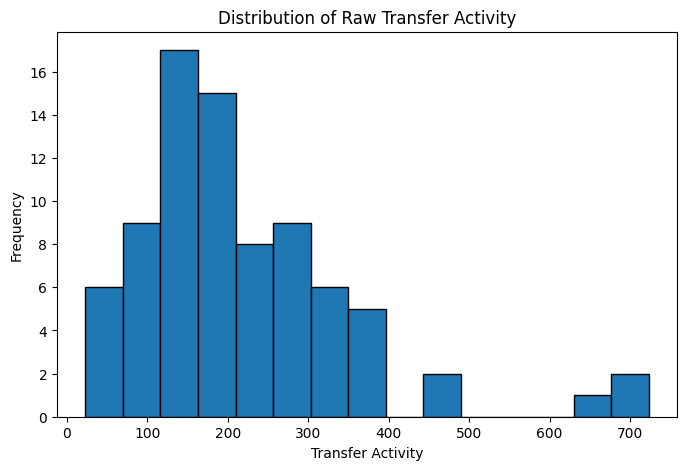

In [22]:
import matplotlib.pyplot as plt

# Summary statistics
print(transfer_model["Transfer_Activity"].describe())
print("Skewness:", transfer_model["Transfer_Activity"].skew())

# Histogram of raw transfer activity
plt.figure(figsize=(8, 5))
plt.hist(transfer_model["Transfer_Activity"], bins=15, edgecolor="black")
plt.xlabel("Transfer Activity")
plt.ylabel("Frequency")
plt.title("Distribution of Raw Transfer Activity")
plt.show()

count    80.000000
mean      5.192843
std       0.652342
min       3.180135
25%       4.855832
50%       5.246260
75%       5.632043
max       6.585206
Name: Log_Transfer_Activity, dtype: float64
Skewness after log transform: -0.6630205009395245


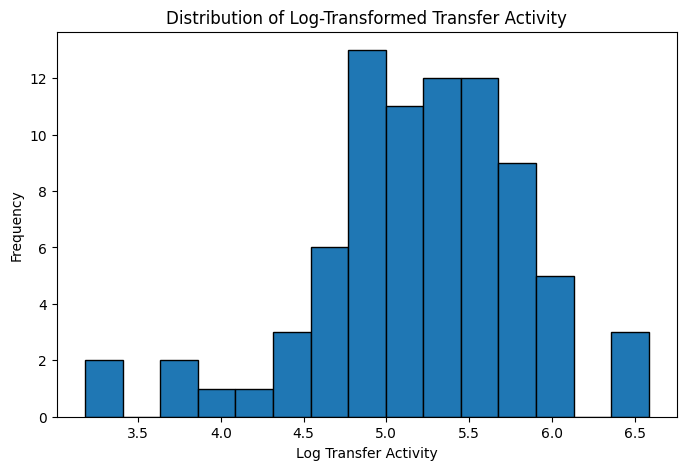

In [23]:
print(transfer_model["Log_Transfer_Activity"].describe())
print("Skewness after log transform:", transfer_model["Log_Transfer_Activity"].skew())

plt.figure(figsize=(8, 5))
plt.hist(transfer_model["Log_Transfer_Activity"], bins=15, edgecolor="black")
plt.xlabel("Log Transfer Activity")
plt.ylabel("Frequency")
plt.title("Distribution of Log-Transformed Transfer Activity")
plt.show()

In [24]:
# Log-transform transfer income
transfer_model["Log_Income"] = np.log1p(
    transfer_model["Summer_Income_EUR_m"]
)

# Standardize income within each season
transfer_model["Income_z"] = (
    transfer_model
    .groupby("Season")["Log_Income"]
    .transform(
        lambda x: (x - x.mean()) / x.std()
    )
)

In [25]:
transfer_strength_df = transfer_strength_df.merge(
    transfer_model[
        [
            "Season",
            "Team",
            "Expenditure_z",
            "Income_z"
        ]
    ],
    on=["Season", "Team"],
    how="left"
)

In [26]:
print(transfer_strength_df.shape)

transfer_strength_df[
    [
        "Season",
        "Team",
        "Delta_S",
        "Expenditure_z",
        "Income_z",
        "Transfer_Activity_z"
    ]
].head(10)

(68, 12)


,Season,Team,Delta_S,Expenditure_z,Income_z,Transfer_Activity_z
0,2022-23,Arsenal,1.534466,0.483432,0.004882,0.196610
1,2022-23,Aston Villa,0.277631,-0.382090,0.404318,-0.295807
2,2022-23,Brentford,0.785554,-0.890128,-1.217899,-1.451646
3,2022-23,Brighton,1.425598,-0.963972,1.120809,0.243590
4,2022-23,Chelsea,-2.761110,1.627611,0.615975,1.459422
5,2022-23,Crystal Palace,-1.026182,-1.340932,-0.971444,-1.835577
6,2022-23,Everton,0.293957,-0.147399,0.633909,0.052395
7,2022-23,Leeds,0.201711,0.240314,1.111950,0.745888
8,2022-23,Leicester,-0.582842,-2.288161,0.876354,-0.490851
9,2022-23,Liverpool,-1.721440,0.092223,0.864812,0.412315


## 4. Mean Transition Effect of Summer Transfers

Before modelling cross-season transition uncertainty, the systematic component of strength change associated with summer transfer activity is estimated.

For each team $i$ entering season $t$, the observed change in strength is modelled as

$$
\Delta S_{i,t} = \alpha + \beta_E E_{z,i,t} + \beta_I I_{z,i,t} + \varepsilon_{i,t}
$$

where $E_{z,i,t}$ and $I_{z,i,t}$ denote season-standardized log expenditure and transfer income, respectively.

The coefficients are estimated from the 68 observations corresponding to teams that remained in the Premier League across consecutive seasons.

The fitted component represents the systematic cross-season strength change associated with transfer-market behaviour, while the residual

$$
\varepsilon_{i,t} = \Delta S_{i,t} - \widehat{\Delta S}_{i,t}
$$


captures the remaining strength change that is not explained by transfer expenditure and income. These residuals will subsequently be used to study transition uncertainty.


In [27]:
import statsmodels.api as sm

# Response variable
y = transfer_strength_df["Delta_S"]

# Transfer variables used to explain the direction of strength change
X = transfer_strength_df[
    [
        "Expenditure_z",
        "Income_z"
    ]
].copy()

X = sm.add_constant(X)

mean_transition_model = sm.OLS(
    y,
    X
).fit()

print(mean_transition_model.summary())

                            OLS Regression Results                            
Dep. Variable:                Delta_S   R-squared:                       0.064
Model:                            OLS   Adj. R-squared:                  0.035
Method:                 Least Squares   F-statistic:                     2.226
Date:                Mon, 24 Aug 2026   Prob (F-statistic):              0.116
Time:                        17:19:33   Log-Likelihood:                -89.700
No. Observations:                  68   AIC:                             185.4
Df Residuals:                      65   BIC:                             192.1
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const            -0.0150      0.116     -0.129

### 4.1 Mean Transition Regression Results

The estimated transition equation is

$$
\widehat{\Delta S}_{i,t}
-0.015
+
0.111E_{z,i,t}
-
0.300I_{z,i,t}.
$$

The model explains approximately 6.4% of the observed cross-season variation in team strength $R^2=0.064$. The overall regression is not statistically significant at the 5% level $p=0.116$, indicating that transfer expenditure and income alone explain only a limited fraction of cross-season strength changes.

The expenditure coefficient is positive but statistically weak $\hat{\beta}_E=0.111,\ p=0.332$. In contrast, transfer income has a negative estimated association with subsequent strength change $\hat{\beta}_I=-0.300,\ p=0.045$ under conventional OLS standard errors.

These estimates are interpreted as associations rather than causal effects. Because the subsequent analysis explicitly investigates whether transition variance changes with transfer activity, heteroskedasticity-robust standard errors are also examined before drawing conclusions about the mean-transition coefficients.

The fitted transition model is retained at this stage primarily to separate systematic mean variation from the remaining transition residuals. Whether transfer information should ultimately modify the Bayesian prior mean will be determined by later validation rather than by in-sample significance alone.


In [28]:
transfer_strength_df["Delta_S_predicted"] = (
    mean_transition_model.predict(X)
)

transfer_strength_df["Transition_Residual"] = (
    transfer_strength_df["Delta_S"]
    - transfer_strength_df["Delta_S_predicted"]
)

In [29]:
transfer_strength_df[
    [
        "Season",
        "Team",
        "Delta_S",
        "Delta_S_predicted",
        "Transition_Residual",
        "Expenditure_z",
        "Income_z"
    ]
].head(10)

,Season,Team,Delta_S,Delta_S_predicted,Transition_Residual,Expenditure_z,Income_z
0,2022-23,Arsenal,1.534466,0.037234,1.497232,0.483432,0.004882
1,2022-23,Aston Villa,0.277631,-0.178592,0.456222,-0.382090,0.404318
2,2022-23,Brentford,0.785554,0.250710,0.534844,-0.890128,-1.217899
3,2022-23,Brighton,1.425598,-0.457830,1.883428,-0.963972,1.120809
4,2022-23,Chelsea,-2.761110,-0.018570,-2.742540,1.627611,0.615975
5,2022-23,Crystal Palace,-1.026182,0.126796,-1.152978,-1.340932,-0.971444
6,2022-23,Everton,0.293957,-0.221254,0.515211,-0.147399,0.633909
7,2022-23,Leeds,0.201711,-0.321306,0.523017,0.240314,1.111950
8,2022-23,Leicester,-0.582842,-0.531827,-0.051015,-2.288161,0.876354
9,2022-23,Liverpool,-1.721440,-0.263762,-1.457678,0.092223,0.864812


In [30]:
mean_transition_model_hc3 = (
    mean_transition_model
    .get_robustcov_results(cov_type="HC3")
)

print(mean_transition_model_hc3.summary())

                            OLS Regression Results                            
Dep. Variable:                Delta_S   R-squared:                       0.064
Model:                            OLS   Adj. R-squared:                  0.035
Method:                 Least Squares   F-statistic:                     2.498
Date:                Mon, 24 Aug 2026   Prob (F-statistic):             0.0902
Time:                        17:19:33   Log-Likelihood:                -89.700
No. Observations:                  68   AIC:                             185.4
Df Residuals:                      65   BIC:                             192.1
Df Model:                           2                                         
Covariance Type:                  HC3                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const            -0.0150      0.115     -0.130

### 4.2 Summary of Mean-Transition Regression

The cross-season mean-transition model was estimated as

$$
\Delta S_{i,t}
=
\alpha
+
\beta_E E_{z,i,t}
+
\beta_I I_{z,i,t}
+
\varepsilon_{i,t}.
$$

The fitted coefficients are

$$
\widehat{\Delta S}_{i,t}
=
-0.015
+
0.111 E_{z,i,t}
-
0.300 I_{z,i,t}.
$$

Two inference procedures were examined. The conventional OLS model assumes constant residual variance, while the HC3 version retains the same fitted coefficients but uses heteroskedasticity-robust standard errors.

The expenditure coefficient is positive but weak and statistically insignificant under both procedures:

$$
\hat{\beta}_E = 0.111,
$$

with $p=0.332$ under conventional OLS and $p=0.324$ using HC3 robust standard errors.

The transfer-income coefficient is negative:

$$
\hat{\beta}_I = -0.300,
$$

with $p=0.045$ under conventional OLS and $p=0.041$ under HC3. This suggests that, conditional on expenditure, unusually high transfer income is associated with a subsequent decline in the estimated strength index.

However, the overall explanatory power of the model is limited:

$$
R^2 = 0.064.
$$

Therefore, expenditure and income together explain only about 6.4% of the observed variation in cross-season strength changes. The model is not statistically significant at the conventional 5% level as a whole, although the HC3 robust joint test provides weak evidence at approximately the 10% level.

Because the substantive conclusions remain similar after using heteroskedasticity-robust standard errors, the estimated mean relationship is considered reasonably robust to the constant-variance assumption. Nevertheless, the low explanatory power indicates that transfer expenditure and income should not automatically be treated as strong predictors of the next-season prior mean.

The main purpose of this regression is therefore to separate the systematic transfer-related component of strength change from the remaining unexplained transition component:

$$
\varepsilon_{i,t}
=
\Delta S_{i,t}
-
\widehat{\Delta S}_{i,t}.
$$

These transition residuals are used in the following section to investigate cross-season uncertainty.

## 5. Transfer Activity and Transition Uncertainty

The mean-transition regression separates the observed cross-season strength change into a systematic component and an unexplained transition residual:

$$
\Delta S_{i,t}
=
\widehat{\Delta S}_{i,t}
+
\varepsilon_{i,t}.
$$

The residual $\varepsilon_{i,t}$ represents the component of cross-season strength change that cannot be explained by the estimated expenditure and income effects.

The next objective is to investigate whether the magnitude of this unexplained transition is related to summer squad turnover.

If highly active transfer windows make the next-season strength state less predictable, then teams with larger transfer activity should tend to exhibit larger residual deviations:

$$
A_{z,i,t} \uparrow
\quad\Rightarrow\quad
|\varepsilon_{i,t}| \uparrow.
$$

This relationship is important for the Bayesian model because it provides a potential empirical basis for the process variance $Q_{i,t}$ used when propagating the posterior strength estimate from one season to the next.

In [31]:
transfer_strength_df["Abs_Transition_Residual"] = (
    transfer_strength_df["Transition_Residual"].abs()
)

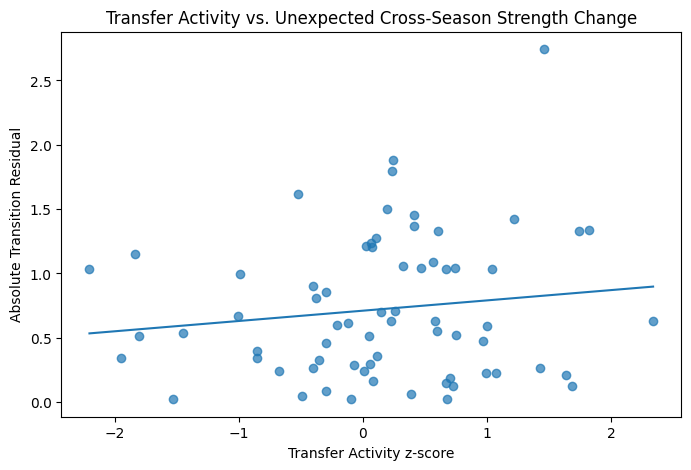

In [32]:
import matplotlib.pyplot as plt
import numpy as np

x = transfer_strength_df["Transfer_Activity_z"]
y = transfer_strength_df["Abs_Transition_Residual"]

plt.figure(figsize=(8, 5))

plt.scatter(x, y, alpha=0.7)

# Linear trend line for visual inspection
coef = np.polyfit(x, y, 1)
trend = np.poly1d(coef)

x_line = np.linspace(x.min(), x.max(), 100)
plt.plot(x_line, trend(x_line))

plt.xlabel("Transfer Activity z-score")
plt.ylabel("Absolute Transition Residual")
plt.title(
    "Transfer Activity vs. Unexpected Cross-Season Strength Change"
)

plt.show()

In [33]:
from scipy.stats import pearsonr, spearmanr

pearson_r, pearson_p = pearsonr(
    transfer_strength_df["Transfer_Activity_z"],
    transfer_strength_df["Abs_Transition_Residual"]
)

spearman_r, spearman_p = spearmanr(
    transfer_strength_df["Transfer_Activity_z"],
    transfer_strength_df["Abs_Transition_Residual"]
)

print(
    f"Pearson correlation: {pearson_r:.3f}, "
    f"p-value: {pearson_p:.4f}"
)

print(
    f"Spearman correlation: {spearman_r:.3f}, "
    f"p-value: {spearman_p:.4f}"
)

Pearson correlation: 0.135, p-value: 0.2708
Spearman correlation: 0.102, p-value: 0.4084


### 5.1 Exploratory Relationship with Absolute Transition Residuals

The relationship between transfer activity and the magnitude of the unexplained cross-season transition was first examined using the absolute transition residual.

The Pearson correlation between standardized transfer activity and absolute transition residuals is

$$
r = 0.135,
$$

with a p-value of 0.271.

The corresponding Spearman rank correlation is

$$
\rho = 0.102,
$$

with a p-value of 0.408.

Both measures indicate only a weak positive relationship, and neither provides statistically significant evidence that more active transfer windows are systematically associated with larger unexpected strength changes.

Although the scatter plot shows a slightly positive fitted trend, the observations remain widely dispersed. Therefore, transfer activity should not yet be assumed to determine the Bayesian transition variance.

Because transition variance is mathematically related to squared deviations rather than absolute deviations, the squared transition residual is examined next.

In [34]:
transfer_strength_df["Transition_Residual_sq"] = (
    transfer_strength_df["Transition_Residual"] ** 2
)

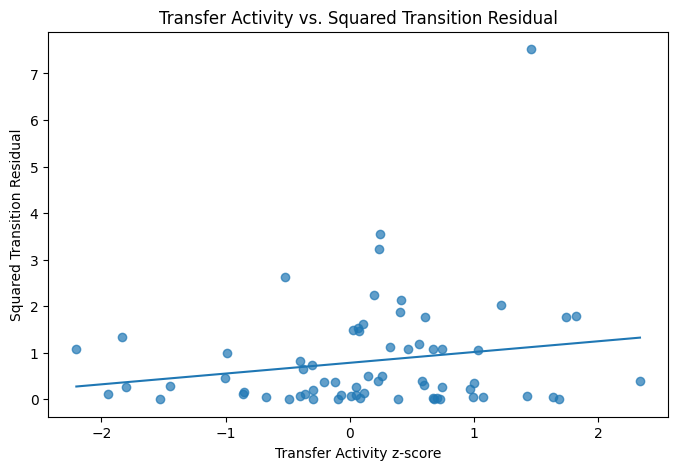

In [35]:
x = transfer_strength_df["Transfer_Activity_z"]
y = transfer_strength_df["Transition_Residual_sq"]

plt.figure(figsize=(8, 5))

plt.scatter(x, y, alpha=0.7)

coef = np.polyfit(x, y, 1)
trend = np.poly1d(coef)

x_line = np.linspace(x.min(), x.max(), 100)
plt.plot(x_line, trend(x_line))

plt.xlabel("Transfer Activity z-score")
plt.ylabel("Squared Transition Residual")
plt.title("Transfer Activity vs. Squared Transition Residual")

plt.show()

In [36]:
import statsmodels.api as sm

X_var = sm.add_constant(
    transfer_strength_df["Transfer_Activity_z"]
)

y_var = transfer_strength_df["Transition_Residual_sq"]

variance_model = sm.OLS(
    y_var,
    X_var
).fit(cov_type="HC3")

print(variance_model.summary())

                              OLS Regression Results                              
Dep. Variable:     Transition_Residual_sq   R-squared:                       0.034
Model:                                OLS   Adj. R-squared:                  0.019
Method:                     Least Squares   F-statistic:                     1.602
Date:                    Mon, 24 Aug 2026   Prob (F-statistic):              0.210
Time:                            17:19:34   Log-Likelihood:                -105.49
No. Observations:                      68   AIC:                             215.0
Df Residuals:                          66   BIC:                             219.4
Df Model:                               1                                         
Covariance Type:                      HC3                                         
                          coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------

### 5.2 Squared Residual Analysis

Because Bayesian transition uncertainty is represented by a variance, the squared transition residual was also examined:

$$
\varepsilon_{i,t}^{2}.
$$

A heteroskedasticity-robust linear regression was estimated as

$$
\varepsilon_{i,t}^{2}
=
\gamma_0
+
\gamma_1 A_{z,i,t}
+
u_{i,t}.
$$

The estimated transfer-activity coefficient is positive,

$$
\hat{\gamma}_1 = 0.232,
$$

but is not statistically significant under HC3 robust inference $p=0.206$. The model explains only approximately 3.4% of the variation in squared transition residuals.

This result is consistent with the earlier Pearson and Spearman analyses: more active transfer windows exhibit a weak tendency toward larger transition deviations, but the available data do not provide sufficient evidence for a stable relationship.

Therefore, transfer activity is not used to directly determine team-specific transition variance in the Bayesian model. A simpler common process-variance structure is retained unless additional information provides stronger evidence for heterogeneous transition uncertainty.

## 6. Team Instability and Bayesian Variance

The instability index $U$ measures residual within-season performance variability after controlling for opponent strength.

Because the unified strength index is defined at the team-season level rather than separately for home and away matches, the venue-specific instability measures must first be combined into a single team-season instability measure.

The home and away instability indices are treated as standard-deviation-type quantities. Therefore, their squared values are averaged before taking the square root:

$$
U_{i,t}
=
\sqrt{
\frac{
U_{H,i,t}^{2}
+
U_{A,i,t}^{2}
}{2}
}.
$$

This preserves the variance-based interpretation of the original instability measure and provides a single long-run instability quantity for each team-season observation.

In [37]:
u_df = pd.read_excel(
    "team_strength_all_results.xlsx",
    sheet_name="Instability_U"
)

# Keep Premier League only
u_e0 = u_df[
    u_df["League"] == "E0"
].copy()

print(u_e0.shape)
print(u_e0.groupby("Season").size())

u_e0.head()

(200, 8)
Season
2021-22    40
2022-23    40
2023-24    40
2024-25    40
2025-26    40
dtype: int64


,League,Season,Team,Venue,N_Features,Trace_Residual_Covariance,Mean_Residual_Variance,Instability_Index_U
0,E0,2021-22,Arsenal,Away,4,3.409724,0.852431,0.923272
1,E0,2021-22,Arsenal,Home,4,2.891148,0.722787,0.850169
2,E0,2021-22,Aston Villa,Away,4,3.379738,0.844934,0.919203
3,E0,2021-22,Aston Villa,Home,4,3.426550,0.856638,0.925547
4,E0,2021-22,Brentford,Away,4,2.815680,0.703920,0.838999


In [38]:
u_paired = (
    u_e0
    .pivot(
        index=["Season", "Team"],
        columns="Venue",
        values="Instability_Index_U"
    )
    .reset_index()
)

u_paired.columns.name = None

u_paired = u_paired.rename(
    columns={
        "Home": "U_Home",
        "Away": "U_Away"
    }
)

u_paired.head()

,Season,Team,U_Away,U_Home
0,2021-22,Arsenal,0.923272,0.850169
1,2021-22,Aston Villa,0.919203,0.925547
2,2021-22,Brentford,0.838999,0.940595
3,2021-22,Brighton,0.803749,0.928756
4,2021-22,Burnley,0.855208,0.726764


In [39]:
import numpy as np

u_paired["U_Season"] = np.sqrt(
    (
        u_paired["U_Home"] ** 2
        + u_paired["U_Away"] ** 2
    ) / 2
)

u_paired[
    ["Season", "Team", "U_Home", "U_Away", "U_Season"]
].head(10)

,Season,Team,U_Home,U_Away,U_Season
0,2021-22,Arsenal,0.850169,0.923272,0.887473
1,2021-22,Aston Villa,0.925547,0.919203,0.922381
2,2021-22,Brentford,0.940595,0.838999,0.891246
3,2021-22,Brighton,0.928756,0.803749,0.868504
4,2021-22,Burnley,0.726764,0.855208,0.793589
5,2021-22,Chelsea,0.931504,0.982638,0.957413
6,2021-22,Crystal Palace,0.896873,0.853775,0.875589
7,2021-22,Everton,0.696156,0.914495,0.812691
8,2021-22,Leeds,0.762642,0.840727,0.802635
9,2021-22,Leicester,0.824722,0.821947,0.823336


### 6.1 Unified Team-Season Instability

The original instability index is estimated separately for home and away matches. Since the Bayesian strength state is represented by a single unified team-strength variable, the two venue-specific instability measures are combined into one team-season quantity.

Because $U$ is a standard-deviation-type measure, the home and away quantities are combined on the variance scale:

$$
U_{i,t}
=
\sqrt{
\frac{
U_{H,i,t}^{2}
+
U_{A,i,t}^{2}
}{2}
}.
$$

Home and away observations receive equal weight because a Premier League season contains the same number of home and away league matches for each club.

A larger value of $U_{i,t}$ indicates greater residual performance instability after opponent strength has been controlled for, while a smaller value indicates a more stable underlying performance profile.

count    100.000000
mean       0.918784
std        0.063986
min        0.772055
25%        0.874381
50%        0.922981
75%        0.953632
max        1.085644
Name: U_Season, dtype: float64


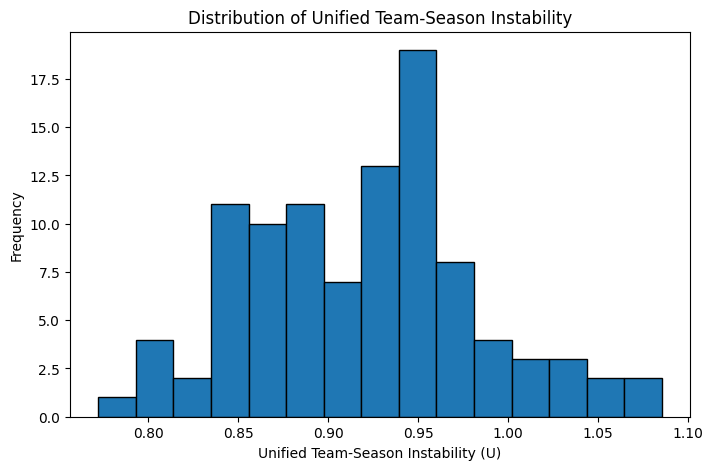

In [40]:
print(u_paired["U_Season"].describe())

plt.figure(figsize=(8, 5))
plt.hist(
    u_paired["U_Season"],
    bins=15,
    edgecolor="black"
)
plt.xlabel("Unified Team-Season Instability (U)")
plt.ylabel("Frequency")
plt.title("Distribution of Unified Team-Season Instability")
plt.show()

In [41]:
next_season_map = {
    "2021-22": "2022-23",
    "2022-23": "2023-24",
    "2023-24": "2024-25",
    "2024-25": "2025-26"
}

u_for_bayes = u_paired[
    ["Season", "Team", "U_Season"]
].copy()

u_for_bayes["Target_Season"] = (
    u_for_bayes["Season"]
    .map(next_season_map)
)

u_for_bayes = (
    u_for_bayes
    .dropna(subset=["Target_Season"])
    .rename(columns={"Season": "U_Source_Season"})
)

u_for_bayes.head(10)

,U_Source_Season,Team,U_Season,Target_Season
0,2021-22,Arsenal,0.887473,2022-23
1,2021-22,Aston Villa,0.922381,2022-23
2,2021-22,Brentford,0.891246,2022-23
3,2021-22,Brighton,0.868504,2022-23
4,2021-22,Burnley,0.793589,2022-23
5,2021-22,Chelsea,0.957413,2022-23
6,2021-22,Crystal Palace,0.875589,2022-23
7,2021-22,Everton,0.812691,2022-23
8,2021-22,Leeds,0.802635,2022-23
9,2021-22,Leicester,0.823336,2022-23


### 6.2 Relative Instability Scaling

The instability index is used to determine the relative process variance of each team rather than the absolute variance scale.

Since $U_{i,t}$ is a standard-deviation-type quantity, its square represents the corresponding residual instability on the variance scale. A relative instability multiplier is therefore defined as

$$
M_{i,t}
=
\frac{U_{i,t}^{2}}
{\overline{U_t^{2}}},
$$

where $\overline{U_t^{2}}$ denotes the mean squared instability across Premier League teams in season $t$.

By construction, the league-average team has

$$
M_{i,t}=1.
$$

Teams with $M_{i,t}>1$ are treated as relatively more unstable, whereas teams with $M_{i,t}<1$ are treated as relatively more stable.

The Bayesian process variance is subsequently represented as

$$
Q_{i,t+1}
=
Q_0 M_{i,t},
$$

where $Q_0$ is a common baseline process variance. Therefore, the instability index determines relative differences in variance across teams, while $Q_0$ determines the overall variance scale of the dynamic Bayesian model.

In [42]:
# Variance-scale instability
u_paired["U2"] = (
    u_paired["U_Season"] ** 2
)

# Mean instability variance within each season
u_paired["Mean_U2_Season"] = (
    u_paired
    .groupby("Season")["U2"]
    .transform("mean")
)

# Relative instability multiplier
u_paired["U_Multiplier"] = (
    u_paired["U2"]
    / u_paired["Mean_U2_Season"]
)

In [43]:
u_paired[
    [
        "Season",
        "Team",
        "U_Season",
        "U2",
        "Mean_U2_Season",
        "U_Multiplier"
    ]
].head(20)

,Season,Team,U_Season,U2,Mean_U2_Season,U_Multiplier
0,2021-22,Arsenal,0.887473,0.787609,0.77924,1.010740
1,2021-22,Aston Villa,0.922381,0.850786,0.77924,1.091815
2,2021-22,Brentford,0.891246,0.794320,0.77924,1.019352
3,2021-22,Brighton,0.868504,0.754300,0.77924,0.967994
4,2021-22,Burnley,0.793589,0.629783,0.77924,0.808202
5,2021-22,Chelsea,0.957413,0.916639,0.77924,1.176325
6,2021-22,Crystal Palace,0.875589,0.766657,0.77924,0.983852
7,2021-22,Everton,0.812691,0.660467,0.77924,0.847578
8,2021-22,Leeds,0.802635,0.644223,0.77924,0.826732
9,2021-22,Leicester,0.823336,0.677882,0.77924,0.869927


In [44]:
next_season_map = {
    "2021-22": "2022-23",
    "2022-23": "2023-24",
    "2023-24": "2024-25",
    "2024-25": "2025-26"
}

u_for_bayes = u_paired[
    [
        "Season",
        "Team",
        "U_Season",
        "U_Multiplier"
    ]
].copy()

u_for_bayes["Target_Season"] = (
    u_for_bayes["Season"]
    .map(next_season_map)
)

u_for_bayes = (
    u_for_bayes
    .dropna(subset=["Target_Season"])
    .rename(
        columns={
            "Season": "U_Source_Season"
        }
    )
)

u_for_bayes.head()

,U_Source_Season,Team,U_Season,U_Multiplier,Target_Season
0,2021-22,Arsenal,0.887473,1.010740,2022-23
1,2021-22,Aston Villa,0.922381,1.091815,2022-23
2,2021-22,Brentford,0.891246,1.019352,2022-23
3,2021-22,Brighton,0.868504,0.967994,2022-23
4,2021-22,Burnley,0.793589,0.808202,2022-23


## 7. Transfer-Based Prior Mean

While the instability index determines the variance of the strength prior, summer transfer activity is treated as a one-time adjustment to the location of the prior distribution.

The baseline assumption is that, in the absence of transfer information, the expected strength of a team at the beginning of a new season equals its posterior strength from the previous season:

$$
\mu_{i,t}^{prior}
=
\mu_{i,t-1}^{post}.
$$

Summer transfers may shift this initial state. Based on the previously estimated transition regression, the transfer-specific mean adjustment is defined as

$$
T_{i,t}
=
\beta_E E_{z,i,t}
+
\beta_I I_{z,i,t}.
$$

The common regression intercept is excluded from the transfer adjustment because it does not represent team-specific transfer information.

The transfer-enhanced prior mean is therefore

$$
\mu_{i,t}^{prior}
=
\mu_{i,t-1}^{post}
+
T_{i,t}.
$$

This adjustment is applied only once at the beginning of each season. It represents an external shock to the team's initial strength state rather than a persistent effect repeatedly applied throughout the season.

In [51]:
beta_E = mean_transition_model.params["Expenditure_z"]
beta_I = mean_transition_model.params["Income_z"]

print(f"beta_E = {beta_E:.6f}")
print(f"beta_I = {beta_I:.6f}")

beta_E = 0.111162
beta_I = -0.299452


In [52]:
transfer_strength_df["Transfer_Mean_Adjustment"] = (
    beta_E * transfer_strength_df["Expenditure_z"]
    +
    beta_I * transfer_strength_df["Income_z"]
)

transfer_strength_df[
    [
        "Season",
        "Team",
        "Expenditure_z",
        "Income_z",
        "Transfer_Mean_Adjustment"
    ]
].head(20)

,Season,Team,Expenditure_z,Income_z,Transfer_Mean_Adjustment
0,2022-23,Arsenal,0.483432,0.004882,0.052278
1,2022-23,Aston Villa,-0.382090,0.404318,-0.163548
2,2022-23,Brentford,-0.890128,-1.217899,0.265754
3,2022-23,Brighton,-0.963972,1.120809,-0.442786
4,2022-23,Chelsea,1.627611,0.615975,-0.003526
5,2022-23,Crystal Palace,-1.340932,-0.971444,0.141840
6,2022-23,Everton,-0.147399,0.633909,-0.206211
7,2022-23,Leeds,0.240314,1.111950,-0.306262
8,2022-23,Leicester,-2.288161,0.876354,-0.516783
9,2022-23,Liverpool,0.092223,0.864812,-0.248718


In [53]:
# Initial strength state from 2021-22
mu_initial = (
    strength_df[
        strength_df["Season"] == "2021-22"
    ][["Team", "S"]]
    .rename(columns={"S": "Mu_Previous"})
)

# Transfer adjustment for the first Bayesian transition
transfer_2223 = (
    transfer_strength_df[
        transfer_strength_df["Season"] == "2022-23"
    ][
        [
            "Team",
            "Transfer_Mean_Adjustment"
        ]
    ]
    .drop_duplicates()
)

mu_2223 = mu_initial.merge(
    transfer_2223,
    on="Team",
    how="inner"
)

mu_2223["Mu_Prior"] = (
    mu_2223["Mu_Previous"]
    +
    mu_2223["Transfer_Mean_Adjustment"]
)

mu_2223.head(20)

,Team,Mu_Previous,Transfer_Mean_Adjustment,Mu_Prior
0,Arsenal,0.435698,0.052278,0.487976
1,Aston Villa,0.467211,-0.163548,0.303662
2,Brentford,-0.455542,0.265754,-0.189789
3,Brighton,-0.107825,-0.442786,-0.550612
4,Chelsea,2.077189,-0.003526,2.073663
5,Crystal Palace,-0.077596,0.141840,0.064244
6,Everton,-1.245301,-0.206211,-1.451511
7,Leeds,-1.389777,-0.306262,-1.696039
8,Leicester,0.300689,-0.516783,-0.216094
9,Liverpool,3.133562,-0.248718,2.884844


In [54]:
import pandas as pd
import numpy as np
import statsmodels.api as sm

# Data required for transfer mean validation
rolling_df = (
    transfer_strength_df[
        [
            "Season",
            "Team",
            "Delta_S",
            "Expenditure_z",
            "Income_z"
        ]
    ]
    .dropna()
    .drop_duplicates()
    .copy()
)

season_order = [
    "2022-23",
    "2023-24",
    "2024-25",
    "2025-26"
]

rolling_results = []

# First season is used for initial training
for test_idx in range(1, len(season_order)):

    train_seasons = season_order[:test_idx]
    test_season = season_order[test_idx]

    train = rolling_df[
        rolling_df["Season"].isin(train_seasons)
    ].copy()

    test = rolling_df[
        rolling_df["Season"] == test_season
    ].copy()

    # Fit transfer -> Delta S using past seasons only
    X_train = sm.add_constant(
        train[["Expenditure_z", "Income_z"]]
    )

    y_train = train["Delta_S"]

    model = sm.OLS(
        y_train,
        X_train
    ).fit()

    beta_E = model.params["Expenditure_z"]
    beta_I = model.params["Income_z"]

    # Baseline:
    # no transfer effect, so predicted Delta S = 0
    test["Pred_DeltaS_Baseline"] = 0.0

    # Transfer-enhanced prediction
    # intercept is deliberately excluded because it is not
    # interpreted as a transfer-specific shock
    test["Pred_DeltaS_Transfer"] = (
        beta_E * test["Expenditure_z"]
        +
        beta_I * test["Income_z"]
    )

    test["Error_Baseline"] = (
        test["Delta_S"]
        - test["Pred_DeltaS_Baseline"]
    )

    test["Error_Transfer"] = (
        test["Delta_S"]
        - test["Pred_DeltaS_Transfer"]
    )

    test["Train_Seasons"] = ", ".join(train_seasons)
    test["Test_Season"] = test_season
    test["Beta_E"] = beta_E
    test["Beta_I"] = beta_I

    rolling_results.append(test)

rolling_oos = pd.concat(
    rolling_results,
    ignore_index=True
)

rolling_oos.head()

,Season,Team,Delta_S,Expenditure_z,Income_z,Pred_DeltaS_Baseline,Pred_DeltaS_Transfer,Error_Baseline,Error_Transfer,Train_Seasons,Test_Season,Beta_E,Beta_I
0,2023-24,Arsenal,1.023612,1.061846,0.394947,0.0,-0.341810,1.023612,1.365422,2022-23,2023-24,-0.177412,-0.388471
1,2023-24,Aston Villa,-0.356958,-0.250173,-0.045540,0.0,0.062075,-0.356958,-0.419033,2022-23,2023-24,-0.177412,-0.388471
2,2023-24,Bournemouth,1.345062,0.221465,-1.594796,0.0,0.580242,1.345062,0.764820,2022-23,2023-24,-0.177412,-0.388471
3,2023-24,Brentford,-0.882888,-0.757217,-0.697442,0.0,0.405276,-0.882888,-1.288164,2022-23,2023-24,-0.177412,-0.388471
4,2023-24,Brighton,-1.367695,-0.180666,0.988982,0.0,-0.352139,-1.367695,-1.015556,2022-23,2023-24,-0.177412,-0.388471


In [55]:
baseline_rmse = np.sqrt(
    np.mean(
        rolling_oos["Error_Baseline"] ** 2
    )
)

transfer_rmse = np.sqrt(
    np.mean(
        rolling_oos["Error_Transfer"] ** 2
    )
)

baseline_mae = np.mean(
    np.abs(rolling_oos["Error_Baseline"])
)

transfer_mae = np.mean(
    np.abs(rolling_oos["Error_Transfer"])
)

comparison = pd.DataFrame({
    "Model": [
        "Previous-season S only",
        "Previous-season S + Transfer"
    ],
    "RMSE": [
        baseline_rmse,
        transfer_rmse
    ],
    "MAE": [
        baseline_mae,
        transfer_mae
    ]
})

comparison

,Model,RMSE,MAE
0,Previous-season S only,0.809140,0.655282
1,Previous-season S + Transfer,0.824886,0.669277


In [56]:
rmse_improvement = (
    (baseline_rmse - transfer_rmse)
    / baseline_rmse
    * 100
)

mae_improvement = (
    (baseline_mae - transfer_mae)
    / baseline_mae
    * 100
)

print(
    f"RMSE improvement from transfer: "
    f"{rmse_improvement:.2f}%"
)

print(
    f"MAE improvement from transfer: "
    f"{mae_improvement:.2f}%"
)

RMSE improvement from transfer: -1.95%
MAE improvement from transfer: -2.14%


In [57]:
season_comparison = (
    rolling_oos
    .groupby("Test_Season")
    .apply(
        lambda x: pd.Series({
            "Baseline_RMSE": np.sqrt(
                np.mean(x["Error_Baseline"] ** 2)
            ),
            "Transfer_RMSE": np.sqrt(
                np.mean(x["Error_Transfer"] ** 2)
            ),
            "Baseline_MAE": np.mean(
                np.abs(x["Error_Baseline"])
            ),
            "Transfer_MAE": np.mean(
                np.abs(x["Error_Transfer"])
            )
        })
    )
)

season_comparison

C:\Users\TK\AppData\Local\Temp\ipykernel_3316\1761100873.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(


,Baseline_RMSE,Transfer_RMSE,Baseline_MAE,Transfer_MAE
Test_Season,,,,
2023-24,0.889989,0.984536,0.779384,0.858929
2024-25,0.667108,0.696122,0.522130,0.587356
2025-26,0.852648,0.766428,0.664332,0.561546


### Net-Spend Robustness Check

As a final robustness check, transfer expenditure and income are replaced by a single net-spending measure.

Net spending is defined as expenditure minus transfer income. Because the variable may take both positive and negative values and contains several large observations, a signed-log transformation is applied:

$$
N_{i,t}^{log}
=
\operatorname{sign}(N_{i,t})
\log(1+|N_{i,t}|).
$$

The transformed variable is standardized within each season and used in the transition model

$$
\Delta S_{i,t}
=
\alpha
+
\beta_N N_{z,i,t}
+
\varepsilon_{i,t}.
$$

Predictive performance is evaluated using the same expanding-window out-of-sample procedure. The net-spending model is compared against the baseline assumption

$$
\widehat{\Delta S}_{i,t}=0,
$$

which corresponds to carrying the previous season's strength estimate forward without a transfer adjustment.

If net spending fails to improve out-of-sample RMSE and MAE, financial transfer variables will be excluded from the final Bayesian prior.

In [65]:
# Signed-log transformation of net spend
transfer_model["Net_Spend_SignedLog"] = (
    np.sign(transfer_model["Net_Spend_EUR_m"])
    * np.log1p(np.abs(transfer_model["Net_Spend_EUR_m"]))
)

# Standardize within each season
transfer_model["Net_Spend_z"] = (
    transfer_model
    .groupby("Season")["Net_Spend_SignedLog"]
    .transform(
        lambda x: (x - x.mean()) / x.std()
    )
)

transfer_model[
    [
        "Season",
        "Team",
        "Net_Spend_EUR_m",
        "Net_Spend_SignedLog",
        "Net_Spend_z"
    ]
].head()

,Season,Team,Net_Spend_EUR_m,Net_Spend_SignedLog,Net_Spend_z
160,2022-23,Bournemouth,26.90,3.328627,0.168762
161,2022-23,Arsenal,107.60,4.687671,0.595164
162,2022-23,Aston Villa,28.00,3.367296,0.180895
163,2022-23,Brentford,44.65,3.821004,0.323246
164,2022-23,Brighton,-68.70,-4.244200,-2.207221


In [66]:
net_spend_df = delta_s_df.merge(
    transfer_model[
        [
            "Season",
            "Team",
            "Net_Spend_EUR_m",
            "Net_Spend_z"
        ]
    ],
    on=["Season", "Team"],
    how="inner",
    validate="one_to_one"
)

print(net_spend_df.shape)
print(net_spend_df.groupby("Season").size())

net_spend_df.head()

(68, 7)
Season
2022-23    17
2023-24    17
2024-25    17
2025-26    17
dtype: int64


,Team,S_current,S_previous,Season,Delta_S,Net_Spend_EUR_m,Net_Spend_z
0,Arsenal,1.970164,0.435698,2022-23,1.534466,107.60,0.595164
1,Aston Villa,0.744841,0.467211,2022-23,0.277631,28.00,0.180895
2,Brentford,0.330011,-0.455542,2022-23,0.785554,44.65,0.323246
3,Brighton,1.317773,-0.107825,2022-23,1.425598,-68.70,-2.207221
4,Chelsea,-0.683921,2.077189,2022-23,-2.761110,244.19,0.850671


In [67]:
import statsmodels.api as sm

season_order = [
    "2022-23",
    "2023-24",
    "2024-25",
    "2025-26"
]

net_oos_results = []

for test_idx in range(1, len(season_order)):

    train_seasons = season_order[:test_idx]
    test_season = season_order[test_idx]

    train = net_spend_df[
        net_spend_df["Season"].isin(train_seasons)
    ].copy()

    test = net_spend_df[
        net_spend_df["Season"] == test_season
    ].copy()

    # Fit using past seasons only
    X_train = sm.add_constant(
        train[["Net_Spend_z"]],
        has_constant="add"
    )

    model = sm.OLS(
        train["Delta_S"],
        X_train
    ).fit()

    # Predict next season
    X_test = sm.add_constant(
        test[["Net_Spend_z"]],
        has_constant="add"
    )

    test["Pred_Baseline"] = 0.0
    test["Pred_NetSpend"] = model.predict(X_test)

    test["Error_Baseline"] = (
        test["Delta_S"] - test["Pred_Baseline"]
    )

    test["Error_NetSpend"] = (
        test["Delta_S"] - test["Pred_NetSpend"]
    )

    test["Beta_NetSpend"] = model.params["Net_Spend_z"]
    test["Intercept"] = model.params["const"]
    test["Test_Season"] = test_season

    net_oos_results.append(test)

net_oos = pd.concat(
    net_oos_results,
    ignore_index=True
)

In [68]:
baseline_rmse = np.sqrt(
    np.mean(net_oos["Error_Baseline"] ** 2)
)

net_rmse = np.sqrt(
    np.mean(net_oos["Error_NetSpend"] ** 2)
)

baseline_mae = np.mean(
    np.abs(net_oos["Error_Baseline"])
)

net_mae = np.mean(
    np.abs(net_oos["Error_NetSpend"])
)

net_comparison = pd.DataFrame({
    "Model": [
        "Previous-season S only",
        "Previous-season S + Net Spend"
    ],
    "RMSE": [
        baseline_rmse,
        net_rmse
    ],
    "MAE": [
        baseline_mae,
        net_mae
    ]
})

net_comparison

,Model,RMSE,MAE
0,Previous-season S only,0.809140,0.655282
1,Previous-season S + Net Spend,0.833623,0.671630


In [69]:
print(
    "RMSE improvement:",
    f"{(baseline_rmse - net_rmse) / baseline_rmse * 100:.2f}%"
)

print(
    "MAE improvement:",
    f"{(baseline_mae - net_mae) / baseline_mae * 100:.2f}%"
)

RMSE improvement: -3.03%
MAE improvement: -2.49%


In [70]:
net_season_comparison = (
    net_oos
    .groupby("Test_Season")
    .apply(
        lambda x: pd.Series({
            "Baseline_RMSE": np.sqrt(
                np.mean(x["Error_Baseline"] ** 2)
            ),
            "NetSpend_RMSE": np.sqrt(
                np.mean(x["Error_NetSpend"] ** 2)
            ),
            "Baseline_MAE": np.mean(
                np.abs(x["Error_Baseline"])
            ),
            "NetSpend_MAE": np.mean(
                np.abs(x["Error_NetSpend"])
            )
        })
    )
)

net_season_comparison

C:\Users\TK\AppData\Local\Temp\ipykernel_3316\2504086345.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(


,Baseline_RMSE,NetSpend_RMSE,Baseline_MAE,NetSpend_MAE
Test_Season,,,,
2023-24,0.889989,0.960848,0.779384,0.834220
2024-25,0.667108,0.661244,0.522130,0.527584
2025-26,0.852648,0.851064,0.664332,0.653086


In [71]:
net_coef_table = (
    net_oos[
        [
            "Test_Season",
            "Intercept",
            "Beta_NetSpend"
        ]
    ]
    .drop_duplicates()
    .reset_index(drop=True)
)

net_coef_table

,Test_Season,Intercept,Beta_NetSpend
0,2023-24,-0.213811,-0.021629
1,2024-25,-0.009952,0.068776
2,2025-26,0.036555,0.084785


### Transfer Information and Model Selection

Summer transfer information was initially considered as a potential source of information for the Bayesian prior. Both expenditure/income variables and net spending were evaluated as predictors of season-to-season changes in the unified strength index.

However, expanding-window out-of-sample validation showed that transfer-based models did not consistently improve predictive performance relative to the simple baseline of carrying the previous season's strength estimate forward.

Therefore, financial transfer variables are excluded from the final Bayesian prior mean. The prior mean is instead defined recursively as

$$
\mu_{i,t}^{prior}
=
\mu_{i,t-1}^{post}.
$$

This choice favors the simpler specification when additional transfer information does not demonstrate stable out-of-sample predictive value.

## 8. Construction of the Bayesian Strength Prior

For the first version of the Bayesian model, a Normal distribution is adopted as the working distribution for the latent team-strength state.

Let

$$
\theta_{i,t}
$$

denote the latent underlying strength of team $i$ in season $t$. This quantity is not directly observed. Instead, the unified Strength Index $S_{i,t}$, constructed from match-performance data, is treated as an empirical estimate of this underlying state.

The Normal distribution is selected as a baseline modeling assumption based on the structure of the Strength Index rather than on inspection of future-season observations. The index is continuous, has no fixed natural upper or lower bound, and is constructed from multiple standardized performance components. In addition, the Normal specification provides a transparent conjugate Bayesian updating framework.

The prior distribution of the latent strength state is therefore defined as

$$
\theta_{i,t}
\sim
\mathcal{N}
\left(
\mu_{i,t}^{prior},
Q_{i,t}
\right).
$$

Here, $\mu_{i,t}^{prior}$ represents the expected strength of team $i$ before observing information from season $t$, while $Q_{i,t}$ represents the uncertainty associated with this prior belief.

### Prior Mean

Transfer-related variables were investigated as possible predictors of season-to-season changes in the Strength Index. However, they did not provide stable out-of-sample improvement over the simpler baseline specification. Transfer information is therefore excluded from the final Bayesian prior.

The prior mean is carried forward recursively from the previous season's posterior strength estimate:

$$
\mu_{i,t}^{prior}
=
\mu_{i,t-1}^{post}.
$$

This allows information accumulated from previous seasons to propagate naturally through the Bayesian sequence without manually averaging historical Strength Index values.

Because 2021/22 is the first season in the Bayesian sequence, no previous posterior is available for initialization. The observed Strength Index from 2021/22 is therefore used as the initial state estimate.

For the first Bayesian transition,

$$
\mu_{i,2022/23}^{prior}
=
S_{i,2021/22}.
$$

After the first update, subsequent prior means are generated recursively from the previous posterior rather than directly from the previous observed Strength Index.

### Prior Variance

The prior variance is determined using the lagged instability index $U$.

The instability index measures residual performance variability after controlling for opponent strength. Since $U$ is a standard-deviation-type quantity, its square is used to represent instability on the variance scale.

A relative instability multiplier is defined as

$$
M_{i,t-1}
=
\frac{
U_{i,t-1}^{2}
}{
\overline{U_{t-1}^{2}}
}.
$$

By construction, the league-average team has

$$
M_{i,t-1}=1.
$$

A team with $M_{i,t-1}>1$ is treated as relatively more unstable, while a team with $M_{i,t-1}<1$ is treated as relatively more stable.

The team-specific prior variance is then defined as

$$
Q_{i,t}
=
Q_0M_{i,t-1},
$$

or equivalently,

$$
Q_{i,t}
=
Q_0
\frac{
U_{i,t-1}^{2}
}{
\overline{U_{t-1}^{2}}
}.
$$

Here, $Q_0$ represents the baseline prior variance of a team with league-average instability.

Therefore, the prior mean and prior variance have separate interpretations:

- $\mu_{i,t}^{prior}$ determines where the team's expected strength is centered.
- $Q_{i,t}$ determines how uncertain that prior strength estimate is.

The complete prior specification is

$$
\boxed{
\theta_{i,t}
\sim
\mathcal{N}
\left(
\mu_{i,t}^{prior},
Q_{i,t}
\right)
}
$$

with

$$
\mu_{i,t}^{prior}
=
\mu_{i,t-1}^{post}
$$

and

$$
Q_{i,t}
=
Q_0
\frac{
U_{i,t-1}^{2}
}{
\overline{U_{t-1}^{2}}
}.
$$

For the initial 2022/23 transition,

$$
\boxed{
\theta_{i,2022/23}
\sim
\mathcal{N}
\left(
S_{i,2021/22},
Q_{i,2022/23}
\right)
}
$$

The empirical distribution of the observed Strength Index is examined in the following subsection only as a diagnostic check of the Normal working assumption, rather than as a procedure for selecting the prior distribution.

### 8.1 Empirical Diagnostic of the Normal Working Assumption

The pooled empirical distribution of the unified Strength Index is inspected as a diagnostic check of the previously specified Normal working assumption.

This diagnostic does not determine the prior distribution and does not estimate the prior parameters. In particular, the pooled values represent different teams and seasons rather than repeated samples from a single latent state.

The histogram, Normal Q-Q plot, skewness, kurtosis, and Shapiro-Wilk test are therefore used only to identify whether the Normal approximation is clearly inconsistent with the observed scale and shape of the Strength Index.

In [72]:
from scipy import stats
import matplotlib.pyplot as plt

s_values = strength_df["S"].dropna()

print("Number of observations:", len(s_values))
print(f"Mean: {s_values.mean():.4f}")
print(f"Standard deviation: {s_values.std():.4f}")
print(f"Skewness: {stats.skew(s_values):.4f}")
print(f"Excess kurtosis: {stats.kurtosis(s_values):.4f}")

shapiro_stat, shapiro_p = stats.shapiro(s_values)

print(f"Shapiro-Wilk statistic: {shapiro_stat:.4f}")
print(f"Shapiro-Wilk p-value: {shapiro_p:.4f}")

Number of observations: 100
Mean: -0.0000
Standard deviation: 1.3297
Skewness: 0.1767
Excess kurtosis: 0.4005
Shapiro-Wilk statistic: 0.9796
Shapiro-Wilk p-value: 0.1246


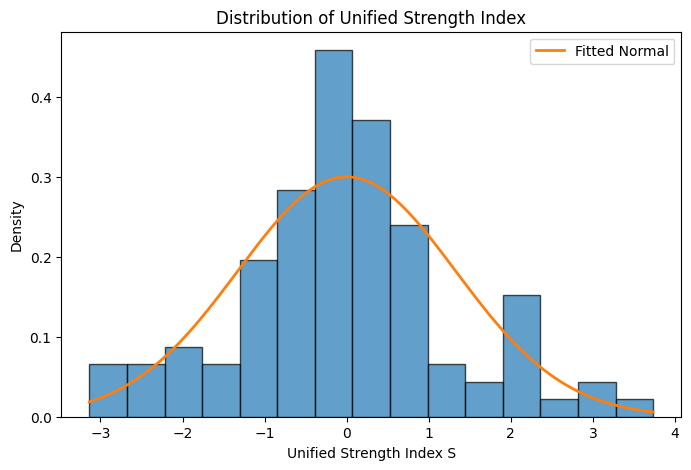

In [73]:
plt.figure(figsize=(8, 5))

plt.hist(
    s_values,
    bins=15,
    density=True,
    edgecolor="black",
    alpha=0.7
)

x = np.linspace(
    s_values.min(),
    s_values.max(),
    300
)

normal_pdf = stats.norm.pdf(
    x,
    loc=s_values.mean(),
    scale=s_values.std(ddof=1)
)

plt.plot(
    x,
    normal_pdf,
    linewidth=2,
    label="Fitted Normal"
)

plt.xlabel("Unified Strength Index S")
plt.ylabel("Density")
plt.title("Distribution of Unified Strength Index")
plt.legend()

plt.show()

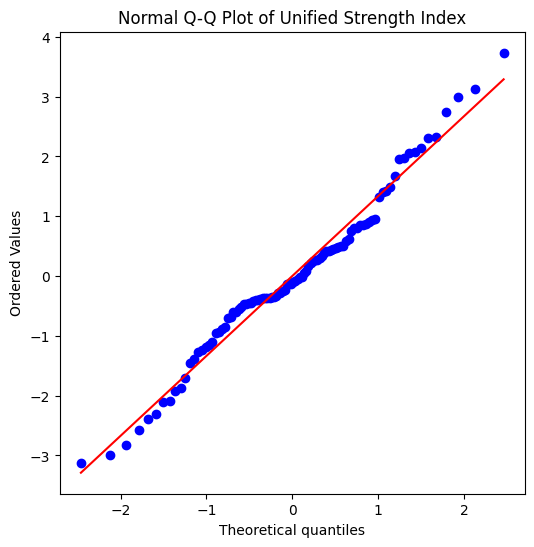

In [74]:
plt.figure(figsize=(6, 6))

stats.probplot(
    s_values,
    dist="norm",
    plot=plt
)

plt.title("Normal Q-Q Plot of Unified Strength Index")
plt.show()

In [75]:
shapiro_stat, shapiro_p = stats.shapiro(s_values)

print(f"Shapiro-Wilk statistic: {shapiro_stat:.4f}")
print(f"Shapiro-Wilk p-value:   {shapiro_p:.4f}")

Shapiro-Wilk statistic: 0.9796
Shapiro-Wilk p-value:   0.1246


#### Diagnostic Result

The empirical diagnostics do not indicate a major contradiction with the Normal working assumption.

The histogram is broadly unimodal and approximately symmetric, while most observations in the Normal Q-Q plot remain close to the reference line. Some deviations are visible in the tails, but they are not sufficiently severe to motivate a more complex distribution in the first version of the model.

The Shapiro-Wilk test gives

$$
p = 0.1246,
$$

so Normality is not rejected at the conventional 5% significance level.

These results are interpreted as supporting the adequacy of the Normal approximation rather than proving that the Strength Index is exactly Normally distributed. The Normal specification is therefore retained for the baseline Bayesian model.

The final season-opening prior for team $i$ is therefore

$$
\theta_{i,0}
\sim
\mathcal{N}
\left(
\mu_{i,0},
Q_0M_{i,t-1}
\right).
$$

The relative uncertainty multiplier $M_{i,t-1}$ is determined from historical team instability, while the common baseline scale $Q_0$ is left uncalibrated at this stage.

The value of $Q_0$ will be estimated jointly with the match-level likelihood parameters using historical sequential match updates.

## 9. Match-Level Likelihood

After constructing the season-opening prior for latent team strength, the next step is to define how new match results provide evidence for updating that strength.

For match $m$, let the observed home goal difference be

$$
D_m = G_{H,m} - G_{A,m}.
$$

The proposed likelihood assumes that goal difference is related to the difference in latent team strength:

$$
D_m
=
h
+
\beta
\left(
\theta_{H,m} - \theta_{A,m}
\right)
+
\varepsilon_m,
$$

where

$$
\varepsilon_m \sim \mathcal{N}(0,R).
$$

Therefore,

$$
D_m
\mid
\theta_{H,m},\theta_{A,m}
\sim
\mathcal{N}
\left(
h+\beta(\theta_{H,m}-\theta_{A,m}),
R
\right).
$$

Here, $h$ represents the average home advantage, $\beta$ maps the latent strength difference onto the goal-difference scale, and $R$ represents match-level randomness not explained by team strength.

### 9.1 Preliminary Likelihood Sanity Check

Before using this likelihood in sequential Bayesian updating, its basic relationship is checked empirically.

To avoid using information from the same season to explain its own match outcomes, the previous season's unified Strength Index is used as a temporary proxy for latent strength:

$$
\theta_{i,t} \approx S_{i,t-1}.
$$

For each match in season \(t\), define

$$
\Delta S_m
=
S_{H,t-1} - S_{A,t-1}.
$$

The preliminary regression is therefore

$$
D_m
=
h+\beta\Delta S_m+\varepsilon_m.
$$

This regression is not the final Bayesian likelihood calibration. Its purpose is only to determine whether previous-season strength differences contain a meaningful directional signal for subsequent match goal differences.

Matches involving teams without a previous-season EPL Strength Index are excluded from this preliminary check.

In [90]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import pearsonr
import statsmodels.api as sm

# -----------------------------
# 1. Load data
# -----------------------------
matches = pd.read_csv("e0_matches_5seasons.csv")
strength = pd.read_excel("unified_strength_index.xlsx")

matches["Season"] = matches["Season"].astype(str)
strength["Season"] = strength["Season"].astype(str)

# Actual home goal difference
matches["GoalDiff"] = matches["FTHG"] - matches["FTAG"]

# -----------------------------
# 2. Map each target season
#    to its previous season
# -----------------------------
prev_season = {
    "2022-23": "2021-22",
    "2023-24": "2022-23",
    "2024-25": "2023-24",
    "2025-26": "2024-25",
}

test_matches = matches[
    matches["Season"].isin(prev_season)
].copy()

test_matches["PriorSeason"] = (
    test_matches["Season"].map(prev_season)
)

# -----------------------------
# 3. Attach previous-season S
#    to home and away teams
# -----------------------------
home_strength = strength.rename(
    columns={
        "Season": "PriorSeason",
        "Team": "HomeTeam",
        "S": "S_Home_Prev"
    }
)

away_strength = strength.rename(
    columns={
        "Season": "PriorSeason",
        "Team": "AwayTeam",
        "S": "S_Away_Prev"
    }
)

df = test_matches.merge(
    home_strength[
        ["PriorSeason", "HomeTeam", "S_Home_Prev"]
    ],
    on=["PriorSeason", "HomeTeam"],
    how="left"
)

df = df.merge(
    away_strength[
        ["PriorSeason", "AwayTeam", "S_Away_Prev"]
    ],
    on=["PriorSeason", "AwayTeam"],
    how="left"
)

# -----------------------------
# 4. For now, remove matches
#    involving teams without
#    previous-season EPL strength
# -----------------------------
print("Matches before dropping missing prior S:", len(df))

df = df.dropna(
    subset=["S_Home_Prev", "S_Away_Prev", "GoalDiff"]
).copy()

print("Matches used:", len(df))

# Strength difference
df["StrengthDiff"] = (
    df["S_Home_Prev"] - df["S_Away_Prev"]
)

display(
    df[
        [
            "Season",
            "HomeTeam",
            "AwayTeam",
            "GoalDiff",
            "S_Home_Prev",
            "S_Away_Prev",
            "StrengthDiff"
        ]
    ].head(10)
)

Matches before dropping missing prior S: 1520
Matches used: 1088


,Season,HomeTeam,AwayTeam,GoalDiff,S_Home_Prev,S_Away_Prev,StrengthDiff
0,2022-23,Crystal Palace,Arsenal,-2,-0.077596,0.435698,-0.513295
3,2022-23,Leeds,Wolves,1,-1.389777,-0.372868,-1.016910
5,2022-23,Tottenham,Southampton,3,0.592544,-0.517747,1.110291
6,2022-23,Everton,Chelsea,-1,-1.245301,2.077189,-3.322490
7,2022-23,Leicester,Brentford,0,0.300689,-0.455542,0.756231
8,2022-23,Man United,Brighton,-1,0.217385,-0.107825,0.325210
9,2022-23,West Ham,Man City,-2,-0.010763,3.733919,-3.744682
10,2022-23,Aston Villa,Everton,1,0.467211,-1.245301,1.712511
11,2022-23,Arsenal,Leicester,2,0.435698,0.300689,0.135009
12,2022-23,Brighton,Newcastle,0,-0.107825,-0.235165,0.127339


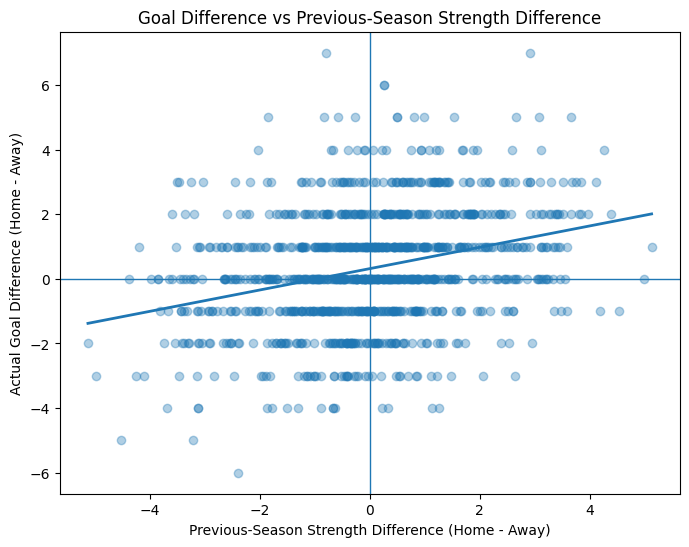

In [91]:
plt.figure(figsize=(8, 6))

plt.scatter(
    df["StrengthDiff"],
    df["GoalDiff"],
    alpha=0.35
)

# Least-squares line
slope, intercept = np.polyfit(
    df["StrengthDiff"],
    df["GoalDiff"],
    1
)

x_line = np.linspace(
    df["StrengthDiff"].min(),
    df["StrengthDiff"].max(),
    200
)

plt.plot(
    x_line,
    intercept + slope * x_line,
    linewidth=2
)

plt.axhline(0, linewidth=1)
plt.axvline(0, linewidth=1)

plt.xlabel("Previous-Season Strength Difference (Home - Away)")
plt.ylabel("Actual Goal Difference (Home - Away)")
plt.title("Goal Difference vs Previous-Season Strength Difference")

plt.show()

In [92]:
X = sm.add_constant(df["StrengthDiff"])
y = df["GoalDiff"]

model = sm.OLS(y, X).fit()

print(model.summary())

h_hat = model.params["const"]
beta_hat = model.params["StrengthDiff"]

R_hat = np.var(model.resid, ddof=2)

print("\nInitial likelihood sanity-check estimates")
print("-----------------------------------------")
print(f"h     = {h_hat:.4f}")
print(f"beta  = {beta_hat:.4f}")
print(f"R     = {R_hat:.4f}")
print(f"SD    = {np.sqrt(R_hat):.4f}")

r, p = pearsonr(
    df["StrengthDiff"],
    df["GoalDiff"]
)

print(f"\nPearson r = {r:.4f}")
print(f"p-value   = {p:.6g}")

                            OLS Regression Results                            
Dep. Variable:               GoalDiff   R-squared:                       0.090
Model:                            OLS   Adj. R-squared:                  0.089
Method:                 Least Squares   F-statistic:                     107.3
Date:                Wed, 26 Aug 2026   Prob (F-statistic):           4.90e-24
Time:                        01:20:14   Log-Likelihood:                -2141.6
No. Observations:                1088   AIC:                             4287.
Df Residuals:                    1086   BIC:                             4297.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const            0.3171      0.053      6.032   

### Preliminary Result

The preliminary relationship is positive and statistically significant.

The estimated regression is approximately

$$
D_m
=
0.317
+
0.331\,\Delta S_m
+
\varepsilon_m.
$$

The positive intercept is consistent with a home-advantage effect, while the positive coefficient on previous-season strength difference confirms that stronger home teams tend, on average, to achieve larger goal differences.

The relationship is statistically significant $p<0.001$, although the explanatory power is intentionally limited $R^2 \approx 0.09$. This is reasonable because individual football matches contain substantial match-level randomness that is not captured by season-level team strength.

Therefore, the result supports using

$$
D_m
\mid
\theta_{H,m},\theta_{A,m}
\sim
\mathcal{N}
\left(
h+\beta(\theta_{H,m}-\theta_{A,m}),
R
\right)
$$

as the baseline match-level likelihood structure.

The coefficients obtained here are diagnostic estimates only; the final values of \(h\), \(\beta\), and \(R\) will be calibrated within the full sequential Bayesian model.

In [93]:
import pandas as pd
import numpy as np

# Load historical instability table
instability = pd.read_excel(
    "team_strength_all_results.xlsx",
    sheet_name="Instability_U"
)

print(instability.columns.tolist())
display(instability.head())

['League', 'Season', 'Team', 'Venue', 'N_Features', 'Trace_Residual_Covariance', 'Mean_Residual_Variance', 'Instability_Index_U']


,League,Season,Team,Venue,N_Features,Trace_Residual_Covariance,Mean_Residual_Variance,Instability_Index_U
0,E0,2021-22,Arsenal,Away,4,3.409724,0.852431,0.923272
1,E0,2021-22,Arsenal,Home,4,2.891148,0.722787,0.850169
2,E0,2021-22,Aston Villa,Away,4,3.379738,0.844934,0.919203
3,E0,2021-22,Aston Villa,Home,4,3.426550,0.856638,0.925547
4,E0,2021-22,Brentford,Away,4,2.815680,0.703920,0.838999


In [95]:
print(instability.columns.tolist())
display(instability.head())

['League', 'Season', 'Team', 'Venue', 'N_Features', 'Trace_Residual_Covariance', 'Mean_Residual_Variance', 'Instability_Index_U']


,League,Season,Team,Venue,N_Features,Trace_Residual_Covariance,Mean_Residual_Variance,Instability_Index_U
0,E0,2021-22,Arsenal,Away,4,3.409724,0.852431,0.923272
1,E0,2021-22,Arsenal,Home,4,2.891148,0.722787,0.850169
2,E0,2021-22,Aston Villa,Away,4,3.379738,0.844934,0.919203
3,E0,2021-22,Aston Villa,Home,4,3.426550,0.856638,0.925547
4,E0,2021-22,Brentford,Away,4,2.815680,0.703920,0.838999


In [105]:
u_wide = (
    instability
    .pivot_table(
        index=["League", "Season", "Team"],
        columns="Venue",
        values="Instability_Index_U",
        aggfunc="first"
    )
    .reset_index()
)

u_wide["U_Combined"] = np.sqrt(
    (u_wide["Home"]**2 + u_wide["Away"]**2) / 2
)

# Normalize instability separately within each league-season
u_wide["M"] = (
    u_wide["U_Combined"]**2
    /
    u_wide.groupby(
        ["League", "Season"]
    )["U_Combined"]
    .transform(lambda x: np.mean(x**2))
)

display(u_wide.head(10))

print(
    u_wide.groupby(
        ["League", "Season"]
    )["M"].mean()
)

Venue,League,Season,Team,Away,Home,U_Combined,M
0,E0,2021-22,Arsenal,0.923272,0.850169,0.887473,1.010740
1,E0,2021-22,Aston Villa,0.919203,0.925547,0.922381,1.091815
2,E0,2021-22,Brentford,0.838999,0.940595,0.891246,1.019352
3,E0,2021-22,Brighton,0.803749,0.928756,0.868504,0.967994
4,E0,2021-22,Burnley,0.855208,0.726764,0.793589,0.808202
5,E0,2021-22,Chelsea,0.982638,0.931504,0.957413,1.176325
6,E0,2021-22,Crystal Palace,0.853775,0.896873,0.875589,0.983852
7,E0,2021-22,Everton,0.914495,0.696156,0.812691,0.847578
8,E0,2021-22,Leeds,0.840727,0.762642,0.802635,0.826732
9,E0,2021-22,Leicester,0.821947,0.824722,0.823336,0.869927


League  Season 
E0      2021-22    1.0
        2022-23    1.0
        2023-24    1.0
        2024-25    1.0
        2025-26    1.0
E1      2021-22    1.0
        2022-23    1.0
        2023-24    1.0
        2024-25    1.0
        2025-26    1.0
Name: M, dtype: float64


## 10. Recursive Cross-Season Bayesian Updating

The final Bayesian specification retains information across seasons rather than restarting from the previous season's empirical Strength Index.

For a retained EPL team, the next season's prior mean is inherited directly from the previous season-end Bayesian posterior:

$$
\mu_{i,0}^{(t)}
=
\mu_{i,\mathrm{end}}^{(t-1)}.
$$

This creates a recursive information chain:

$$
S_{2021-22}
\rightarrow
\theta_{\mathrm{end}}^{2022-23}
\rightarrow
\theta_{\mathrm{end}}^{2023-24}
\rightarrow
\theta_{\mathrm{end}}^{2024-25}
\rightarrow
\theta_{\mathrm{end}}^{2025-26}.
$$

The first replay season, 2022-23, is anchored by the empirical 2021-22 unified Strength Index because no earlier Bayesian posterior is available.

To avoid excessive accumulation of certainty across seasons, posterior variance is **not** carried forward directly. Instead, uncertainty is refreshed at the beginning of each season using the previous season's relative instability multiplier:

$$
P_{i,0}^{(t)}
=
Q_0M_{i,t-1}.
$$

Thus, the model preserves cross-season memory through the prior mean while allowing preseason uncertainty to reset according to recent team instability.

For newly promoted teams, no previous EPL posterior exists. Their opening mean is supplied by the promotion bridge, while their variance multiplier is taken from the previous Championship season.

For historical replay, promoted-team means are estimated using a leave-one-promotion-cohort-out bridge so that the target promotion cohort does not contribute to its own prior calibration.

In [114]:
# ============================================================
# 10. Cross-season Bayesian replay setup
# ============================================================

# Seasons that will actually be replayed.
# 2021-22 is the initial anchor season.
replay_seasons = [
    "2022-23",
    "2023-24",
    "2024-25",
    "2025-26"
]

previous_season = {
    "2022-23": "2021-22",
    "2023-24": "2022-23",
    "2024-25": "2023-24",
    "2025-26": "2024-25"
}

# ------------------------------------------------------------
# Promoted teams entering each EPL season
# ------------------------------------------------------------
promoted_by_season = {
    "2022-23": [
        "Fulham",
        "Bournemouth",
        "Nott'm Forest"
    ],
    "2023-24": [
        "Burnley",
        "Sheffield United",
        "Luton"
    ],
    "2024-25": [
        "Leicester",
        "Ipswich",
        "Southampton"
    ],
    "2025-26": [
        "Leeds",
        "Burnley",
        "Sunderland"
    ]
}

# Flatten for inspection
promotion_rows = []

for epl_season, teams in promoted_by_season.items():
    
    champ_season = previous_season[epl_season]
    
    for team in teams:
        promotion_rows.append({
            "EPL_Season": epl_season,
            "Championship_Season": champ_season,
            "Team": team
        })

historical_promotions = pd.DataFrame(promotion_rows)

display(historical_promotions)

print(
    "\nPromoted teams per EPL season:"
)

print(
    historical_promotions
    .groupby("EPL_Season")
    .size()
)

,EPL_Season,Championship_Season,Team
0,2022-23,2021-22,Fulham
1,2022-23,2021-22,Bournemouth
2,2022-23,2021-22,Nott'm Forest
3,2023-24,2022-23,Burnley
4,2023-24,2022-23,Sheffield United
5,2023-24,2022-23,Luton
6,2024-25,2023-24,Leicester
7,2024-25,2023-24,Ipswich
8,2024-25,2023-24,Southampton
9,2025-26,2024-25,Leeds



Promoted teams per EPL season:
EPL_Season
2022-23    3
2023-24    3
2024-25    3
2025-26    3
dtype: int64


In [115]:
# ============================================================
# 11. Leakage-free historical promoted-team priors
# ============================================================

# ------------------------------------------------------------
# 1. Attach next-season EPL strength to the 12 historical
#    promoted teams
# ------------------------------------------------------------
historical_promotion_pairs = historical_promotions.merge(
    strength[["Season", "Team", "S"]].rename(
        columns={
            "Season": "EPL_Season",
            "S": "S_EPL"
        }
    ),
    on=["EPL_Season", "Team"],
    how="left",
    validate="one_to_one"
)

# Check that every historical promoted team has an EPL S
missing_s = historical_promotion_pairs[
    historical_promotion_pairs["S_EPL"].isna()
]

if len(missing_s) > 0:
    display(missing_s)
    raise ValueError(
        "Some historical promoted teams could not be matched to EPL S."
    )


# ------------------------------------------------------------
# 2. Leave-one-promotion-cohort-out bridge mean
# ------------------------------------------------------------
cohort_prior_rows = []

for target_season in replay_seasons:

    # Exclude the entire target promotion cohort
    train = historical_promotion_pairs[
        historical_promotion_pairs["EPL_Season"] != target_season
    ].copy()

    prior_mean = train["S_EPL"].mean()

    target = historical_promotion_pairs[
        historical_promotion_pairs["EPL_Season"] == target_season
    ].copy()

    target["Promoted_Prior_Mean"] = prior_mean

    cohort_prior_rows.append(target)


historical_promoted_prior = pd.concat(
    cohort_prior_rows,
    ignore_index=True
)


# ------------------------------------------------------------
# 3. Attach each promoted team's Championship instability M
# ------------------------------------------------------------
e1_M = (
    u_wide[
        u_wide["League"].eq("E1")
    ][["Season", "Team", "M"]]
    .rename(
        columns={
            "Season": "Championship_Season",
            "M": "Promoted_M"
        }
    )
)

historical_promoted_prior = historical_promoted_prior.merge(
    e1_M,
    on=["Championship_Season", "Team"],
    how="left",
    validate="one_to_one"
)


# ------------------------------------------------------------
# 4. Sanity checks
# ------------------------------------------------------------
missing_m = historical_promoted_prior[
    historical_promoted_prior["Promoted_M"].isna()
]

if len(missing_m) > 0:
    display(missing_m)
    raise ValueError(
        "Some promoted teams are missing Championship M."
    )

assert len(historical_promoted_prior) == 12

print("Historical promoted priors:", len(historical_promoted_prior))

display(
    historical_promoted_prior[
        [
            "EPL_Season",
            "Championship_Season",
            "Team",
            "S_EPL",
            "Promoted_Prior_Mean",
            "Promoted_M"
        ]
    ]
    .sort_values(["EPL_Season", "Team"])
    .reset_index(drop=True)
)


print("\nLeakage-free promoted prior mean by target season:")

display(
    historical_promoted_prior
    .groupby("EPL_Season", as_index=False)
    .agg(
        Promoted_Prior_Mean=("Promoted_Prior_Mean", "first"),
        N_Promoted=("Team", "size")
    )
)

Historical promoted priors: 12


,EPL_Season,Championship_Season,Team,S_EPL,Promoted_Prior_Mean,Promoted_M
0,2022-23,2021-22,Bournemouth,-1.709464,-1.809374,0.927387
1,2022-23,2021-22,Fulham,0.085858,-1.809374,1.125205
2,2022-23,2021-22,Nott'm Forest,-1.453462,-1.809374,0.929373
3,2023-24,2022-23,Burnley,-2.110267,-1.486890,1.202269
4,2023-24,2022-23,Luton,-0.881559,-1.486890,1.118149
5,2023-24,2022-23,Sheffield United,-2.987599,-1.486890,1.010539
6,2024-25,2023-24,Ipswich,-1.928187,-1.332627,0.918666
7,2024-25,2023-24,Leicester,-2.305093,-1.332627,1.179195
8,2024-25,2023-24,Southampton,-3.134512,-1.332627,1.027164
9,2025-26,2024-25,Burnley,-2.088381,-1.824921,1.796593



Leakage-free promoted prior mean by target season:


,EPL_Season,Promoted_Prior_Mean,N_Promoted
0,2022-23,-1.809374,3
1,2023-24,-1.486890,3
2,2024-25,-1.332627,3
3,2025-26,-1.824921,3


In [116]:
# ============================================================
# 12. Recursive Bayesian replay across seasons
# ============================================================

# Initial diagnostic likelihood values from the earlier OLS
h0 = float(model.params["const"])
beta0 = float(model.params["StrengthDiff"])
R0 = float(np.var(model.resid, ddof=2))


def build_opening_state(
    season,
    Q0,
    previous_end_mu=None
):
    """
    Construct the 20-team opening state for one EPL season.

    Retained teams:
        mean = previous season-end Bayesian posterior mean
        M    = previous-season EPL M

    Promoted teams:
        mean = leakage-controlled promotion bridge mean
        M    = previous-season Championship M

    For the first replay season (2022-23), retained-team means
    are initialized from 2021-22 empirical S because no earlier
    Bayesian posterior exists.
    """

    prior_season = previous_season[season]

    # --------------------------------------------------------
    # Current EPL team list
    # --------------------------------------------------------
    season_matches = matches[
        matches["Season"].astype(str).eq(season)
    ]

    current_teams = sorted(
        set(season_matches["HomeTeam"])
        | set(season_matches["AwayTeam"])
    )

    promoted = set(promoted_by_season[season])
    retained = set(current_teams) - promoted

    assert len(current_teams) == 20
    assert len(promoted) == 3
    assert len(retained) == 17

    # --------------------------------------------------------
    # Retained-team prior means
    # --------------------------------------------------------
    if previous_end_mu is None:

        # First recursive season:
        # use 2021-22 empirical S as the initial anchor
        anchor_S = (
            strength[
                strength["Season"].astype(str).eq(prior_season)
            ][["Team", "S"]]
            .set_index("Team")["S"]
            .to_dict()
        )

        retained_mean = {
            team: anchor_S[team]
            for team in retained
        }

    else:

        # Later seasons:
        # carry previous Bayesian posterior mean forward
        missing_retained = [
            team
            for team in retained
            if team not in previous_end_mu
        ]

        if missing_retained:
            raise ValueError(
                f"{season}: retained teams missing from previous "
                f"posterior state: {missing_retained}"
            )

        retained_mean = {
            team: previous_end_mu[team]
            for team in retained
        }

    # --------------------------------------------------------
    # Retained-team M from previous EPL season
    # --------------------------------------------------------
    retained_M_table = (
        u_wide[
            (u_wide["League"].eq("E0"))
            &
            (u_wide["Season"].astype(str).eq(prior_season))
            &
            (u_wide["Team"].isin(retained))
        ][["Team", "M"]]
    )

    retained_M = (
        retained_M_table
        .set_index("Team")["M"]
        .to_dict()
    )

    # --------------------------------------------------------
    # Promoted-team mean and M
    # --------------------------------------------------------
    promoted_table = historical_promoted_prior[
        historical_promoted_prior["EPL_Season"].eq(season)
    ].copy()

    promoted_mean = (
        promoted_table
        .set_index("Team")["Promoted_Prior_Mean"]
        .to_dict()
    )

    promoted_M = (
        promoted_table
        .set_index("Team")["Promoted_M"]
        .to_dict()
    )

    # --------------------------------------------------------
    # Assemble opening table
    # --------------------------------------------------------
    rows = []

    for team in current_teams:

        if team in promoted:

            mu0 = promoted_mean[team]
            M = promoted_M[team]
            source = "Promotion bridge"

        else:

            mu0 = retained_mean[team]
            M = retained_M[team]

            if previous_end_mu is None:
                source = "Initial empirical S"
            else:
                source = "Previous posterior"

        rows.append({
            "Season": season,
            "Team": team,
            "Prior_Mean": mu0,
            "M": M,
            "Prior_Source": source
        })

    opening = pd.DataFrame(rows)

    opening["Prior_Variance"] = (
        Q0 * opening["M"]
    )

    return opening


def replay_across_seasons(
    Q0,
    h=h0,
    beta=beta0,
    R=R0,
    return_history=False
):
    """
    Sequential Bayesian replay over all four EPL seasons.

    Cross-season memory:
        previous season-end posterior mean
        -> next season opening prior mean

    Cross-season variance:
        reset each season to Q0 * previous-season M
    """

    total_loglik = 0.0

    all_history = []
    opening_states = []
    ending_states = []

    previous_end_mu = None

    # ========================================================
    # Loop through seasons
    # ========================================================
    for season in replay_seasons:

        # ----------------------------------------------------
        # 1. Build season-opening state
        # ----------------------------------------------------
        opening = build_opening_state(
            season=season,
            Q0=Q0,
            previous_end_mu=previous_end_mu
        )

        opening_states.append(opening.copy())

        teams = opening["Team"].tolist()
        n_teams = len(teams)

        team_to_idx = {
            team: i
            for i, team in enumerate(teams)
        }

        mu = opening["Prior_Mean"].to_numpy(
            dtype=float
        )

        # Fresh covariance every new season
        P = np.diag(
            opening["Prior_Variance"].to_numpy(
                dtype=float
            )
        )

        # ----------------------------------------------------
        # 2. Season matches in chronological order
        # ----------------------------------------------------
        data = matches[
            matches["Season"].astype(str).eq(season)
        ].copy()

        if "GoalDiff" not in data.columns:
            data["GoalDiff"] = (
                data["FTHG"] - data["FTAG"]
            )

        parsed_date = pd.to_datetime(
            data["Date"],
            dayfirst=True,
            errors="coerce"
        )

        if parsed_date.notna().all():
            data["_DateSort"] = parsed_date

            data = (
                data
                .sort_values(
                    ["_DateSort", "HomeTeam"]
                )
                .reset_index(drop=True)
            )
        else:
            data = data.reset_index(drop=True)

        season_loglik = 0.0

        # ----------------------------------------------------
        # 3. Sequential match updates
        # ----------------------------------------------------
        for match_number, row in data.iterrows():

            home = row["HomeTeam"]
            away = row["AwayTeam"]
            D = float(row["GoalDiff"])

            i = team_to_idx[home]
            j = team_to_idx[away]

            # Home - Away contrast
            x = np.zeros(n_teams)
            x[i] = 1.0
            x[j] = -1.0

            H = beta * x

            # Pre-match prediction
            pred_mean = (
                h + H @ mu
            )

            PH = P @ H

            pred_var = (
                H @ PH + R
            )

            residual = (
                D - pred_mean
            )

            # Gaussian predictive log-likelihood
            loglik = -0.5 * (
                np.log(2 * np.pi * pred_var)
                +
                residual**2 / pred_var
            )

            total_loglik += loglik
            season_loglik += loglik

            home_mu_pre = mu[i]
            away_mu_pre = mu[j]

            # ------------------------------------------------
            # Bayesian update
            # ------------------------------------------------
            K = PH / pred_var

            mu = (
                mu + K * residual
            )

            P = (
                P
                - np.outer(PH, PH) / pred_var
            )

            # Numerical symmetry protection
            P = 0.5 * (P + P.T)

            if return_history:

                all_history.append({
                    "Season": season,
                    "Match_Number": match_number + 1,
                    "Date": row.get("Date", np.nan),
                    "HomeTeam": home,
                    "AwayTeam": away,
                    "GoalDiff": D,
                    "Predicted_GoalDiff": pred_mean,
                    "Predictive_Variance": pred_var,
                    "Residual": residual,
                    "LogLik": loglik,
                    "Home_Mean_Pre": home_mu_pre,
                    "Away_Mean_Pre": away_mu_pre,
                    "Home_Mean_Post": mu[i],
                    "Away_Mean_Post": mu[j]
                })

        # ----------------------------------------------------
        # 4. Save season-end posterior means
        # ----------------------------------------------------
        previous_end_mu = {
            team: float(mu[idx])
            for team, idx in team_to_idx.items()
        }

        end_table = pd.DataFrame({
            "Season": season,
            "Team": teams,
            "Posterior_Mean_End": mu,
            "Posterior_Variance_End": np.diag(P)
        })

        end_table["Season_LogLik"] = (
            season_loglik
        )

        ending_states.append(end_table)

    # ========================================================
    # Combine outputs
    # ========================================================
    opening_states = pd.concat(
        opening_states,
        ignore_index=True
    )

    ending_states = pd.concat(
        ending_states,
        ignore_index=True
    )

    if return_history:

        history = pd.DataFrame(
            all_history
        )

        return (
            total_loglik,
            history,
            opening_states,
            ending_states,
            previous_end_mu
        )

    return total_loglik

In [117]:
# ============================================================
# 13. Test recursive replay with provisional parameters
# ============================================================

(
    test_loglik,
    test_history,
    test_opening,
    test_ending,
    test_final_mu
) = replay_across_seasons(
    Q0=1.0,
    h=h0,
    beta=beta0,
    R=R0,
    return_history=True
)

print("Recursive replay test")
print("---------------------")
print("Seasons replayed:", test_history["Season"].nunique())
print("Matches replayed:", len(test_history))
print("Total log-likelihood:", test_loglik)

print("\nOpening-state counts:")
display(
    test_opening
    .groupby(
        ["Season", "Prior_Source"]
    )
    .size()
    .rename("N")
    .reset_index()
)

print("\nSeason-end team counts:")
display(
    test_ending
    .groupby("Season")
    .size()
    .rename("N_Teams")
    .reset_index()
)

Recursive replay test
---------------------
Seasons replayed: 4
Matches replayed: 1520
Total log-likelihood: -2962.4887044081242

Opening-state counts:


,Season,Prior_Source,N
0,2022-23,Initial empirical S,17
1,2022-23,Promotion bridge,3
2,2023-24,Previous posterior,17
3,2023-24,Promotion bridge,3
4,2024-25,Previous posterior,17
5,2024-25,Promotion bridge,3
6,2025-26,Previous posterior,17
7,2025-26,Promotion bridge,3



Season-end team counts:


,Season,N_Teams
0,2022-23,20
1,2023-24,20
2,2024-25,20
3,2025-26,20


In [118]:
# ============================================================
# 14. Joint MLE under recursive cross-season Bayesian replay
# ============================================================

from scipy.optimize import minimize


# ------------------------------------------------------------
# Negative log-likelihood objective
#
# Parameters:
#   z[0] = log(Q0)
#   z[1] = h
#   z[2] = log(beta)
#   z[3] = log(R)
# ------------------------------------------------------------
def recursive_neg_loglik(z):

    log_Q0, h, log_beta, log_R = z

    Q0 = np.exp(log_Q0)
    beta = np.exp(log_beta)
    R = np.exp(log_R)

    try:
        loglik = replay_across_seasons(
            Q0=Q0,
            h=h,
            beta=beta,
            R=R,
            return_history=False
        )

    except Exception:
        return 1e12

    if not np.isfinite(loglik):
        return 1e12

    return -loglik


# ------------------------------------------------------------
# Initial values
# Use the previous model estimates only as optimization seeds
# ------------------------------------------------------------
Q0_start = 0.927544
h_start = 0.317097
beta_start = 0.333671
R_start = 2.793545

z0 = np.array([
    np.log(Q0_start),
    h_start,
    np.log(beta_start),
    np.log(R_start)
])


initial_loglik = -recursive_neg_loglik(z0)


# ------------------------------------------------------------
# Joint numerical optimization
# ------------------------------------------------------------
result_recursive = minimize(
    recursive_neg_loglik,
    z0,
    method="L-BFGS-B",
    bounds=[
        (-6, 3),      # log Q0
        (-2, 2),      # h
        (-6, 2),      # log beta
        (-6, 4)       # log R
    ],
    options={
        "maxiter": 500,
        "ftol": 1e-10
    }
)


# ------------------------------------------------------------
# Recover parameters
# ------------------------------------------------------------
log_Q0_hat, h_hat, log_beta_hat, log_R_hat = (
    result_recursive.x
)

Q0_recursive = np.exp(log_Q0_hat)
h_recursive = h_hat
beta_recursive = np.exp(log_beta_hat)
R_recursive = np.exp(log_R_hat)

final_loglik = -result_recursive.fun


print("Recursive cross-season joint MLE")
print("--------------------------------")
print("Optimization success:", result_recursive.success)
print("Message:", result_recursive.message)

print(f"\nInitial log-likelihood = {initial_loglik:.6f}")
print(f"Final log-likelihood   = {final_loglik:.6f}")
print(
    f"Improvement            = "
    f"{final_loglik - initial_loglik:.6f}"
)

print("\nFinal calibrated parameters")
print("---------------------------")
print(f"Q0   = {Q0_recursive:.6f}")
print(f"h    = {h_recursive:.6f}")
print(f"beta = {beta_recursive:.6f}")
print(f"R    = {R_recursive:.6f}")

Recursive cross-season joint MLE
--------------------------------
Optimization success: True
Message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH

Initial log-likelihood = -2959.527424
Final log-likelihood   = -2958.248241
Improvement            = 1.279184

Final calibrated parameters
---------------------------
Q0   = 0.981691
h    = 0.282894
beta = 0.368582
R    = 2.719278


### Recursive Model Calibration

The recursive model is calibrated by maximizing the sequential predictive likelihood over four complete EPL seasons:

$$
2022\text{-}23,\;
2023\text{-}24,\;
2024\text{-}25,\;
2025\text{-}26,
$$

covering

$$
4\times380=1520
$$

matches.

The jointly estimated parameters are:

$$
\boxed{Q_0=0.981691}
$$

$$
\boxed{h=0.282894}
$$

$$
\boxed{\beta=0.368582}
$$

$$
\boxed{R=2.719278}.
$$

The final sequential log-likelihood is

$$
\log L=-2958.248.
$$

Here, $Q_0$ controls the global scale of preseason uncertainty, $h$ represents the average home advantage in goal difference, $\beta$ links latent strength difference to expected goal difference, and $R$ represents remaining match-level outcome noise.

The recursive replay successfully preserves the season-end posterior mean of retained clubs as the opening prior mean of the following season.

In [119]:
# ============================================================
# 15. Final recursive replay with calibrated parameters
# ============================================================

(
    final_loglik_recursive,
    recursive_history,
    recursive_opening,
    recursive_ending,
    final_mu_2025_26
) = replay_across_seasons(
    Q0=Q0_recursive,
    h=h_recursive,
    beta=beta_recursive,
    R=R_recursive,
    return_history=True
)

print("Final recursive replay")
print("----------------------")
print(f"Total log-likelihood = {final_loglik_recursive:.6f}")
print(f"Matches replayed      = {len(recursive_history)}")
print(f"Seasons replayed      = {recursive_history['Season'].nunique()}")

Final recursive replay
----------------------
Total log-likelihood = -2958.248241
Matches replayed      = 1520
Seasons replayed      = 4


In [140]:
# ============================================================
# Export pre-match Bayesian strength history
# ============================================================

bayesian_match_history = recursive_history[
    [
        "Season",
        "Date",
        "HomeTeam",
        "AwayTeam",
        "Home_Mean_Pre",
        "Away_Mean_Pre",
        "Home_Mean_Post",
        "Away_Mean_Post"
    ]
].copy()

bayesian_match_history.to_csv(
    "bayesian_match_strength_history.csv",
    index=False
)

print("Saved matches:", len(bayesian_match_history))
print("Seasons:", bayesian_match_history["Season"].nunique())

display(bayesian_match_history.head())

Saved matches: 1520
Seasons: 4


,Season,Date,HomeTeam,AwayTeam,Home_Mean_Pre,Away_Mean_Pre,Home_Mean_Post,Away_Mean_Post
0,2022-23,05/08/2022,Crystal Palace,Arsenal,-0.077596,0.435698,-0.327267,0.692192
1,2022-23,06/08/2022,Bournemouth,Aston Villa,-1.809374,0.467211,-1.522360,0.129308
2,2022-23,06/08/2022,Everton,Chelsea,-1.245301,2.077189,-1.251281,2.085488
3,2022-23,06/08/2022,Fulham,Liverpool,-1.809374,3.133562,-1.600107,2.959520
4,2022-23,06/08/2022,Leeds,Wolves,-1.389777,-0.372868,-1.279139,-0.496043


In [120]:
# ============================================================
# 16. Season-level recursive state summary
# ============================================================

season_summary = (
    recursive_history
    .groupby("Season", as_index=False)
    .agg(
        N_Matches=("GoalDiff", "size"),
        RMSE=(
            "Residual",
            lambda x: np.sqrt(np.mean(x**2))
        ),
        MAE=(
            "Residual",
            lambda x: np.mean(np.abs(x))
        ),
        LogLik=("LogLik", "sum")
    )
)

display(season_summary)

,Season,N_Matches,RMSE,MAE,LogLik
0,2022-23,380,1.735020,1.347871,-748.873704
1,2023-24,380,1.803702,1.371395,-765.105366
2,2024-25,380,1.703726,1.351197,-742.056768
3,2025-26,380,1.518741,1.228850,-702.212403


In [121]:
# ============================================================
# 17. Manchester City cross-season Bayesian trajectory
# ============================================================

city_opening = (
    recursive_opening[
        recursive_opening["Team"].eq("Man City")
    ][
        [
            "Season",
            "Prior_Mean",
            "Prior_Variance",
            "Prior_Source"
        ]
    ]
    .copy()
)

city_ending = (
    recursive_ending[
        recursive_ending["Team"].eq("Man City")
    ][
        [
            "Season",
            "Posterior_Mean_End",
            "Posterior_Variance_End"
        ]
    ]
    .copy()
)

city_trajectory = city_opening.merge(
    city_ending,
    on="Season",
    how="inner",
    validate="one_to_one"
)

display(city_trajectory)

,Season,Prior_Mean,Prior_Variance,Prior_Source,Posterior_Mean_End,Posterior_Variance_End
0,2022-23,3.733919,0.890804,Initial empirical S,4.044898,0.350643
1,2023-24,4.044898,1.062115,Previous posterior,4.192742,0.373879
2,2024-25,4.192742,1.203672,Previous posterior,2.730939,0.390467
3,2025-26,2.730939,0.887534,Previous posterior,3.026024,0.350087


### Example of Cross-Season Information Propagation

Manchester City provides a useful illustration of the recursive mechanism.

Its Bayesian strength evolves as

$$
3.734
\rightarrow
4.045
\rightarrow
4.193
\rightarrow
2.731
\rightarrow
3.026,
$$

where each season-end posterior becomes the next season's opening prior mean.

For example,

$$
\mu_{\mathrm{City},0}^{2023-24}
=
\mu_{\mathrm{City},\mathrm{end}}^{2022-23}
=
4.045,
$$

and similarly for subsequent seasons.

The substantial decline from the end of 2023-24 to the end of 2024-25 demonstrates that cross-season memory does not force strength to remain close to its historical level. New match evidence can still move the latent state substantially when observed performance changes.

Therefore, the recursive structure preserves historical information without preventing adaptation to new-season evidence.

## 11. Independent-Season Baseline

To test whether cross-season information actually improves prediction, the recursive model is compared with an independent-season Bayesian baseline.

The baseline uses the **same match likelihood and the same within-season Bayesian updating equations**, but removes all cross-season memory.

At the beginning of every season,

$$
\boldsymbol{\mu}_0=\mathbf{0},
$$

and

$$
\mathbf{P}_0=Q_0\mathbf{I}.
$$

Therefore, every club begins the season from the same neutral strength level and with the same prior uncertainty.

No previous-season Strength Index, instability multiplier, posterior state, or promotion bridge is used.

Once the season begins, however, the baseline learns sequentially from match results in exactly the same way as the recursive model.

This creates a controlled comparison:

$$
\boxed{\text{Recursive model: previous-season information retained}}
$$

versus

$$
\boxed{\text{Baseline: each season starts independently}}
$$

Both models are calibrated separately by maximum likelihood so that the comparison does not favor the recursive model through shared hyperparameters.

In [122]:
# ============================================================
# 18. Independent-season Bayesian baseline
# ============================================================

def replay_season_reset(
    Q0,
    h,
    beta,
    R,
    return_history=False
):
    """
    Independent-season Bayesian baseline.

    Every EPL season starts from scratch:

        mu_0 = 0
        P_0  = Q0 * I

    No previous-season strength, instability, posterior,
    or promotion bridge is carried across seasons.

    Within each season, Bayesian updating is identical
    to the recursive model.
    """

    total_loglik = 0.0

    all_history = []
    opening_states = []
    ending_states = []

    # ========================================================
    # Each season is treated independently
    # ========================================================
    for season in replay_seasons:

        # ----------------------------------------------------
        # 1. Current EPL teams
        # ----------------------------------------------------
        data = matches[
            matches["Season"].astype(str).eq(season)
        ].copy()

        teams = sorted(
            set(data["HomeTeam"])
            | set(data["AwayTeam"])
        )

        n_teams = len(teams)

        assert n_teams == 20

        team_to_idx = {
            team: i
            for i, team in enumerate(teams)
        }

        # ----------------------------------------------------
        # 2. Completely neutral season-opening prior
        # ----------------------------------------------------
        mu = np.zeros(n_teams)

        P = Q0 * np.eye(n_teams)

        opening = pd.DataFrame({
            "Season": season,
            "Team": teams,
            "Prior_Mean": 0.0,
            "Prior_Variance": Q0,
            "Prior_Source": "Season reset"
        })

        opening_states.append(opening)

        # ----------------------------------------------------
        # 3. Chronological ordering
        # ----------------------------------------------------
        if "GoalDiff" not in data.columns:
            data["GoalDiff"] = (
                data["FTHG"] - data["FTAG"]
            )

        parsed_date = pd.to_datetime(
            data["Date"],
            dayfirst=True,
            errors="coerce"
        )

        if parsed_date.notna().all():

            data["_DateSort"] = parsed_date

            data = (
                data
                .sort_values(
                    ["_DateSort", "HomeTeam"]
                )
                .reset_index(drop=True)
            )

        else:
            data = data.reset_index(drop=True)

        season_loglik = 0.0

        # ----------------------------------------------------
        # 4. Sequential Bayesian updates
        # ----------------------------------------------------
        for match_number, row in data.iterrows():

            home = row["HomeTeam"]
            away = row["AwayTeam"]

            D = float(row["GoalDiff"])

            i = team_to_idx[home]
            j = team_to_idx[away]

            x = np.zeros(n_teams)
            x[i] = 1.0
            x[j] = -1.0

            H = beta * x

            # Pre-match prediction
            pred_mean = (
                h + H @ mu
            )

            PH = P @ H

            pred_var = (
                H @ PH + R
            )

            residual = (
                D - pred_mean
            )

            # Predictive log-likelihood
            loglik = -0.5 * (
                np.log(2 * np.pi * pred_var)
                +
                residual**2 / pred_var
            )

            total_loglik += loglik
            season_loglik += loglik

            home_mu_pre = mu[i]
            away_mu_pre = mu[j]

            # ------------------------------------------------
            # Bayesian update
            # ------------------------------------------------
            K = PH / pred_var

            mu = (
                mu + K * residual
            )

            P = (
                P
                - np.outer(PH, PH) / pred_var
            )

            P = 0.5 * (P + P.T)

            if return_history:

                all_history.append({
                    "Season": season,
                    "Match_Number": match_number + 1,
                    "Date": row.get("Date", np.nan),
                    "HomeTeam": home,
                    "AwayTeam": away,
                    "GoalDiff": D,
                    "Predicted_GoalDiff": pred_mean,
                    "Predictive_Variance": pred_var,
                    "Residual": residual,
                    "LogLik": loglik,
                    "Home_Mean_Pre": home_mu_pre,
                    "Away_Mean_Pre": away_mu_pre,
                    "Home_Mean_Post": mu[i],
                    "Away_Mean_Post": mu[j]
                })

        # ----------------------------------------------------
        # 5. Save season-end state
        # ----------------------------------------------------
        end_table = pd.DataFrame({
            "Season": season,
            "Team": teams,
            "Posterior_Mean_End": mu,
            "Posterior_Variance_End": np.diag(P)
        })

        end_table["Season_LogLik"] = season_loglik

        ending_states.append(end_table)

    # ========================================================
    # Combine outputs
    # ========================================================
    opening_states = pd.concat(
        opening_states,
        ignore_index=True
    )

    ending_states = pd.concat(
        ending_states,
        ignore_index=True
    )

    if return_history:

        history = pd.DataFrame(
            all_history
        )

        return (
            total_loglik,
            history,
            opening_states,
            ending_states
        )

    return total_loglik

In [123]:
# ============================================================
# 19. Sanity check for season-reset baseline
# ============================================================

(
    baseline_test_loglik,
    baseline_test_history,
    baseline_test_opening,
    baseline_test_ending
) = replay_season_reset(
    Q0=Q0_recursive,
    h=h_recursive,
    beta=beta_recursive,
    R=R_recursive,
    return_history=True
)

print("Season-reset baseline test")
print("--------------------------")
print("Seasons replayed:", baseline_test_history["Season"].nunique())
print("Matches replayed:", len(baseline_test_history))
print("Total log-likelihood:", baseline_test_loglik)

print("\nOpening priors:")
display(
    baseline_test_opening
    .groupby("Season", as_index=False)
    .agg(
        N_Teams=("Team", "size"),
        Mean_Prior=("Prior_Mean", "mean"),
        Mean_Variance=("Prior_Variance", "mean")
    )
)

print("\nSeason-end team counts:")
display(
    baseline_test_ending
    .groupby("Season")
    .size()
    .rename("N_Teams")
    .reset_index()
)

Season-reset baseline test
--------------------------
Seasons replayed: 4
Matches replayed: 1520
Total log-likelihood: -3006.2792736664746

Opening priors:


,Season,N_Teams,Mean_Prior,Mean_Variance
0,2022-23,20,0.0,0.981691
1,2023-24,20,0.0,0.981691
2,2024-25,20,0.0,0.981691
3,2025-26,20,0.0,0.981691



Season-end team counts:


,Season,N_Teams
0,2022-23,20
1,2023-24,20
2,2024-25,20
3,2025-26,20


In [124]:
# ============================================================
# 20. Joint MLE for independent-season baseline
# ============================================================

def baseline_neg_loglik(z):

    log_Q0, h, log_beta, log_R = z

    Q0 = np.exp(log_Q0)
    beta = np.exp(log_beta)
    R = np.exp(log_R)

    try:

        loglik = replay_season_reset(
            Q0=Q0,
            h=h,
            beta=beta,
            R=R,
            return_history=False
        )

    except Exception:
        return 1e12

    if not np.isfinite(loglik):
        return 1e12

    return -loglik


# Use recursive estimates only as numerical starting values
z0_baseline = np.array([
    np.log(Q0_recursive),
    h_recursive,
    np.log(beta_recursive),
    np.log(R_recursive)
])

baseline_initial_loglik = (
    -baseline_neg_loglik(z0_baseline)
)


result_baseline = minimize(
    baseline_neg_loglik,
    z0_baseline,
    method="L-BFGS-B",
    bounds=[
        (-6, 3),     # log Q0
        (-2, 2),     # h
        (-6, 2),     # log beta
        (-6, 4)      # log R
    ],
    options={
        "maxiter": 500,
        "ftol": 1e-10
    }
)


# Recover fitted parameters
(
    log_Q0_base,
    h_base,
    log_beta_base,
    log_R_base
) = result_baseline.x

Q0_baseline = np.exp(log_Q0_base)
h_baseline = h_base
beta_baseline = np.exp(log_beta_base)
R_baseline = np.exp(log_R_base)

baseline_final_loglik = (
    -result_baseline.fun
)


print("Independent-season baseline MLE")
print("--------------------------------")
print("Optimization success:", result_baseline.success)
print("Message:", result_baseline.message)

print(
    f"\nInitial log-likelihood = "
    f"{baseline_initial_loglik:.6f}"
)

print(
    f"Final log-likelihood   = "
    f"{baseline_final_loglik:.6f}"
)

print(
    f"Improvement            = "
    f"{baseline_final_loglik - baseline_initial_loglik:.6f}"
)

print("\nFinal baseline parameters")
print("-------------------------")
print(f"Q0   = {Q0_baseline:.6f}")
print(f"h    = {h_baseline:.6f}")
print(f"beta = {beta_baseline:.6f}")
print(f"R    = {R_baseline:.6f}")

Independent-season baseline MLE
--------------------------------
Optimization success: True
Message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH

Initial log-likelihood = -3006.279274
Final log-likelihood   = -2988.859004
Improvement            = 17.420269

Final baseline parameters
-------------------------
Q0   = 1.337268
h    = 0.282896
beta = 0.541487
R    = 2.716036


In [126]:
# ============================================================
# 22. Recursive vs independent-season baseline
# ============================================================

def performance_summary(df, model_name):

    return pd.Series({
        "Model": model_name,
        "N_Matches": len(df),
        "RMSE": np.sqrt(
            np.mean(df["Residual"]**2)
        ),
        "MAE": np.mean(
            np.abs(df["Residual"])
        ),
        "LogLik": df["LogLik"].sum()
    })


# ------------------------------------------------------------
# Overall comparison
# ------------------------------------------------------------
overall_comparison = pd.DataFrame([
    performance_summary(
        recursive_history,
        "Recursive Bayesian"
    ),
    performance_summary(
        baseline_history,
        "Independent-season"
    )
])

print("Overall comparison")
display(overall_comparison)


# ------------------------------------------------------------
# Season-by-season comparison
# ------------------------------------------------------------
season_rows = []

for season in replay_seasons:

    rec = recursive_history[
        recursive_history["Season"].eq(season)
    ]

    base = baseline_history[
        baseline_history["Season"].eq(season)
    ]

    for name, df in [
        ("Recursive Bayesian", rec),
        ("Independent-season", base)
    ]:

        season_rows.append({
            "Season": season,
            "Model": name,
            "N_Matches": len(df),
            "RMSE": np.sqrt(
                np.mean(df["Residual"]**2)
            ),
            "MAE": np.mean(
                np.abs(df["Residual"])
            ),
            "LogLik": df["LogLik"].sum()
        })


season_comparison = pd.DataFrame(
    season_rows
)

print("\nSeason-by-season comparison")
display(season_comparison)

Overall comparison


,Model,N_Matches,RMSE,MAE,LogLik
0,Recursive Bayesian,1520,1.693583,1.324828,-2958.248241
1,Independent-season,1520,1.729462,1.344176,-2988.859004



Season-by-season comparison


,Season,Model,N_Matches,RMSE,MAE,LogLik
0,2022-23,Recursive Bayesian,380,1.735020,1.347871,-748.873704
1,2022-23,Independent-season,380,1.758449,1.352243,-753.522349
2,2023-24,Recursive Bayesian,380,1.803702,1.371395,-765.105366
3,2023-24,Independent-season,380,1.865109,1.424482,-778.325121
4,2024-25,Recursive Bayesian,380,1.703726,1.351197,-742.056768
5,2024-25,Independent-season,380,1.729972,1.361796,-748.215797
6,2025-26,Recursive Bayesian,380,1.518741,1.228850,-702.212403
7,2025-26,Independent-season,380,1.549380,1.238182,-708.795737


In [127]:
# ============================================================
# 23. Add pre-match team match counts
# ============================================================

def add_team_match_counts(history):

    df = history.copy()

    home_pre = []
    away_pre = []

    for season in replay_seasons:

        season_df = df[
            df["Season"].eq(season)
        ]

        counts = {}

        for idx, row in season_df.iterrows():

            home = row["HomeTeam"]
            away = row["AwayTeam"]

            home_pre.append(
                (idx, counts.get(home, 0))
            )

            away_pre.append(
                (idx, counts.get(away, 0))
            )

            counts[home] = (
                counts.get(home, 0) + 1
            )

            counts[away] = (
                counts.get(away, 0) + 1
            )

    home_map = dict(home_pre)
    away_map = dict(away_pre)

    df["Home_Matches_Pre"] = (
        df.index.map(home_map)
    )

    df["Away_Matches_Pre"] = (
        df.index.map(away_map)
    )

    df["Both_First5"] = (
        (df["Home_Matches_Pre"] < 5)
        &
        (df["Away_Matches_Pre"] < 5)
    )

    df["Both_First10"] = (
        (df["Home_Matches_Pre"] < 10)
        &
        (df["Away_Matches_Pre"] < 10)
    )

    return df


recursive_eval = add_team_match_counts(
    recursive_history
)

baseline_eval = add_team_match_counts(
    baseline_history
)

In [128]:
# ============================================================
# 24. Early-season vs full-season comparison
# ============================================================

window_rows = []

windows = {
    "First 5 matches/team": "Both_First5",
    "First 10 matches/team": "Both_First10",
    "Full season": None
}

for window_name, flag in windows.items():

    for model_name, df in [
        ("Recursive Bayesian", recursive_eval),
        ("Independent-season", baseline_eval)
    ]:

        if flag is None:
            sub = df
        else:
            sub = df[df[flag]].copy()

        window_rows.append({
            "Window": window_name,
            "Model": model_name,
            "N_Matches": len(sub),
            "RMSE": np.sqrt(
                np.mean(sub["Residual"]**2)
            ),
            "MAE": np.mean(
                np.abs(sub["Residual"])
            ),
            "LogLik": sub["LogLik"].sum(),
            "Mean_LogLik": sub["LogLik"].mean()
        })


window_comparison = pd.DataFrame(
    window_rows
)

display(window_comparison)

,Window,Model,N_Matches,RMSE,MAE,LogLik,Mean_LogLik
0,First 5 matches/team,Recursive Bayesian,199,1.585450,1.196606,-375.420714,-1.886536
1,First 5 matches/team,Independent-season,199,1.807629,1.372457,-399.836677,-2.009230
2,First 10 matches/team,Recursive Bayesian,397,1.588871,1.224570,-749.363547,-1.887566
3,First 10 matches/team,Independent-season,397,1.723575,1.321471,-779.019280,-1.962265
4,Full season,Recursive Bayesian,1520,1.693583,1.324828,-2958.248241,-1.946216
5,Full season,Independent-season,1520,1.729462,1.344176,-2988.859004,-1.966355


### Sequential Baseline Comparison

Across all 1520 historical matches, the recursive specification performs better than the independently calibrated season-reset baseline.

The overall results are:

$$
RMSE_{\mathrm{recursive}}=1.694
<
1.729
=
RMSE_{\mathrm{reset}},
$$

$$
MAE_{\mathrm{recursive}}=1.325
<
1.344
=
MAE_{\mathrm{reset}},
$$

and

$$
\log L_{\mathrm{recursive}}
=
-2958.248
>
-2988.859
=
\log L_{\mathrm{reset}}.
$$

The recursive model also achieves lower RMSE in all four replayed seasons.

More importantly, the advantage is strongest during the beginning of each season.

For matches in which both teams are within their first five league matches,

$$
RMSE:
\qquad
1.585
\text{ vs. }
1.808,
$$

an improvement of approximately

$$
12.3\%.
$$

For the first ten matches per team,

$$
RMSE:
\qquad
1.589
\text{ vs. }
1.724,
$$

corresponding to an improvement of approximately

$$
7.8\%.
$$

Across the complete season sample, the improvement falls to approximately

$$
2.1\%.
$$

This pattern is consistent with the intended role of the Bayesian prior. Historical information is most valuable when little current-season evidence is available. As new matches accumulate, the independent-season model gradually learns the current strength ordering, reducing the advantage of cross-season memory.

Because these results use parameters estimated from the same four-season historical sample, an expanding-window out-of-sample robustness test is conducted next.

## 12. Expanding-Window Out-of-Sample Robustness

The previous comparison preserves the sequential ordering of matches, but model hyperparameters were estimated using the same four-season sample on which performance was evaluated.

To test whether the recursive advantage generalizes to genuinely unseen seasons, an expanding-window backtest is constructed.

Three forecasting folds are used:

$$
2022\text{-}23
\rightarrow
\boxed{2023\text{-}24},
$$

$$
2022\text{-}23+2023\text{-}24
\rightarrow
\boxed{2024\text{-}25},
$$

and

$$
2022\text{-}23+2023\text{-}24+2024\text{-}25
\rightarrow
\boxed{2025\text{-}26}.
$$

For each fold:

1. model parameters are estimated using training seasons only;
2. the fitted parameters are frozen;
3. the following season is evaluated without refitting;
4. both recursive and season-reset models are calibrated independently.

Promotion priors are also restricted to information that would have been historically available before the test season. Therefore, future promotion cohorts are not used to construct historical promoted-team priors.

For the earliest replay season, no earlier promotion cohort with the final unified Strength Index is available, so the promoted-team prior mean is initialized at the neutral value

$$
\mu_{\mathrm{promoted}}=0.
$$

This backtest removes future information from Bayesian hyperparameter calibration and promotion-prior construction.

The unified Strength Index representation itself is treated as a fixed pre-estimated feature system rather than being re-estimated separately within every historical fold.

In [129]:
# ============================================================
# 25. Past-only promotion priors for strict backtesting
# ============================================================

robust_promoted_prior = historical_promoted_prior.copy()

season_position = {
    season: i
    for i, season in enumerate(replay_seasons)
}


def past_only_promotion_mean(target_season):
    """
    Promotion prior using only promotion cohorts whose EPL season
    occurred before the target season.

    For 2022-23 there is no earlier unified-S promotion cohort
    in the current five-season window, so use neutral mean = 0.
    """

    target_pos = season_position[target_season]

    previous_cohorts = historical_promotion_pairs[
        historical_promotion_pairs["EPL_Season"].map(
            season_position
        ) < target_pos
    ]

    if len(previous_cohorts) == 0:
        return 0.0

    return previous_cohorts["S_EPL"].mean()


robust_promoted_prior["PastOnly_Prior_Mean"] = (
    robust_promoted_prior["EPL_Season"]
    .map(past_only_promotion_mean)
)

display(
    robust_promoted_prior[
        [
            "EPL_Season",
            "Team",
            "S_EPL",
            "PastOnly_Prior_Mean",
            "Promoted_M"
        ]
    ]
    .sort_values(["EPL_Season", "Team"])
    .reset_index(drop=True)
)

print("\nPast-only promoted mean by season:")

display(
    robust_promoted_prior
    .groupby("EPL_Season", as_index=False)
    .agg(
        Prior_Mean=("PastOnly_Prior_Mean", "first"),
        N_Promoted=("Team", "size")
    )
)

,EPL_Season,Team,S_EPL,PastOnly_Prior_Mean,Promoted_M
0,2022-23,Bournemouth,-1.709464,0.000000,0.927387
1,2022-23,Fulham,0.085858,0.000000,1.125205
2,2022-23,Nott'm Forest,-1.453462,0.000000,0.929373
3,2023-24,Burnley,-2.110267,-1.025689,1.202269
4,2023-24,Luton,-0.881559,-1.025689,1.118149
5,2023-24,Sheffield United,-2.987599,-1.025689,1.010539
6,2024-25,Ipswich,-1.928187,-1.509415,0.918666
7,2024-25,Leicester,-2.305093,-1.509415,1.179195
8,2024-25,Southampton,-3.134512,-1.509415,1.027164
9,2025-26,Burnley,-2.088381,-1.824921,1.796593



Past-only promoted mean by season:


,EPL_Season,Prior_Mean,N_Promoted
0,2022-23,0.000000,3
1,2023-24,-1.025689,3
2,2024-25,-1.509415,3
3,2025-26,-1.824921,3


In [130]:
# ============================================================
# 26. Generic one-season Bayesian engine
# ============================================================

def run_bayesian_season(
    season,
    opening,
    h,
    beta,
    R,
    return_history=False
):
    """
    Run one full EPL season from a supplied opening state.
    """

    teams = opening["Team"].tolist()
    n_teams = len(teams)

    team_to_idx = {
        team: i
        for i, team in enumerate(teams)
    }

    mu = opening["Prior_Mean"].to_numpy(dtype=float)

    P = np.diag(
        opening["Prior_Variance"].to_numpy(dtype=float)
    )

    data = matches[
        matches["Season"].astype(str).eq(season)
    ].copy()

    if "GoalDiff" not in data.columns:
        data["GoalDiff"] = (
            data["FTHG"] - data["FTAG"]
        )

    parsed_date = pd.to_datetime(
        data["Date"],
        dayfirst=True,
        errors="coerce"
    )

    if parsed_date.notna().all():

        data["_DateSort"] = parsed_date

        data = (
            data
            .sort_values(["_DateSort", "HomeTeam"])
            .reset_index(drop=True)
        )

    else:
        data = data.reset_index(drop=True)

    season_loglik = 0.0
    history_rows = []

    for match_number, row in data.iterrows():

        home = row["HomeTeam"]
        away = row["AwayTeam"]
        D = float(row["GoalDiff"])

        i = team_to_idx[home]
        j = team_to_idx[away]

        x = np.zeros(n_teams)
        x[i] = 1.0
        x[j] = -1.0

        H = beta * x

        pred_mean = h + H @ mu

        PH = P @ H
        pred_var = H @ PH + R

        residual = D - pred_mean

        loglik = -0.5 * (
            np.log(2 * np.pi * pred_var)
            +
            residual**2 / pred_var
        )

        season_loglik += loglik

        K = PH / pred_var

        mu = mu + K * residual

        P = (
            P
            - np.outer(PH, PH) / pred_var
        )

        P = 0.5 * (P + P.T)

        if return_history:

            history_rows.append({
                "Season": season,
                "Match_Number": match_number + 1,
                "Date": row.get("Date", np.nan),
                "HomeTeam": home,
                "AwayTeam": away,
                "GoalDiff": D,
                "Predicted_GoalDiff": pred_mean,
                "Predictive_Variance": pred_var,
                "Residual": residual,
                "LogLik": loglik
            })

    end_mu = {
        team: float(mu[i])
        for team, i in team_to_idx.items()
    }

    end_table = pd.DataFrame({
        "Season": season,
        "Team": teams,
        "Posterior_Mean_End": mu,
        "Posterior_Variance_End": np.diag(P)
    })

    if return_history:

        return (
            season_loglik,
            pd.DataFrame(history_rows),
            end_mu,
            end_table
        )

    return season_loglik, end_mu

In [131]:
# ============================================================
# 27. Strict recursive opening state
# ============================================================

def build_recursive_opening_robust(
    season,
    Q0,
    previous_end_mu=None
):

    prior_season = previous_season[season]

    season_matches = matches[
        matches["Season"].astype(str).eq(season)
    ]

    current_teams = sorted(
        set(season_matches["HomeTeam"])
        |
        set(season_matches["AwayTeam"])
    )

    promoted = set(promoted_by_season[season])
    retained = set(current_teams) - promoted

    # --------------------------------------------------------
    # Retained means
    # --------------------------------------------------------
    if previous_end_mu is None:

        anchor_S = (
            strength[
                strength["Season"].astype(str).eq(prior_season)
            ][["Team", "S"]]
            .set_index("Team")["S"]
            .to_dict()
        )

        retained_mean = {
            team: anchor_S[team]
            for team in retained
        }

    else:

        retained_mean = {
            team: previous_end_mu[team]
            for team in retained
        }

    # --------------------------------------------------------
    # Retained EPL M
    # --------------------------------------------------------
    retained_M = (
        u_wide[
            (u_wide["League"].eq("E0"))
            &
            (u_wide["Season"].astype(str).eq(prior_season))
        ]
        .set_index("Team")["M"]
        .to_dict()
    )

    # --------------------------------------------------------
    # Past-only promoted prior
    # --------------------------------------------------------
    promoted_table = robust_promoted_prior[
        robust_promoted_prior["EPL_Season"].eq(season)
    ]

    promoted_mean = (
        promoted_table
        .set_index("Team")["PastOnly_Prior_Mean"]
        .to_dict()
    )

    promoted_M = (
        promoted_table
        .set_index("Team")["Promoted_M"]
        .to_dict()
    )

    rows = []

    for team in current_teams:

        if team in promoted:

            mu0 = promoted_mean[team]
            M = promoted_M[team]

        else:

            mu0 = retained_mean[team]
            M = retained_M[team]

        rows.append({
            "Season": season,
            "Team": team,
            "Prior_Mean": mu0,
            "Prior_Variance": Q0 * M
        })

    return pd.DataFrame(rows)

In [132]:
# ============================================================
# 28. Recursive and reset replay over arbitrary windows
# ============================================================

def replay_recursive_window(
    seasons,
    Q0,
    h,
    beta,
    R,
    initial_previous_end_mu=None,
    return_history=False
):

    previous_end_mu_local = initial_previous_end_mu

    total_loglik = 0.0
    histories = []

    for season in seasons:

        opening = build_recursive_opening_robust(
            season=season,
            Q0=Q0,
            previous_end_mu=previous_end_mu_local
        )

        if return_history:

            (
                loglik,
                history,
                previous_end_mu_local,
                _
            ) = run_bayesian_season(
                season,
                opening,
                h,
                beta,
                R,
                return_history=True
            )

            histories.append(history)

        else:

            (
                loglik,
                previous_end_mu_local
            ) = run_bayesian_season(
                season,
                opening,
                h,
                beta,
                R,
                return_history=False
            )

        total_loglik += loglik

    if return_history:

        return (
            total_loglik,
            pd.concat(histories, ignore_index=True),
            previous_end_mu_local
        )

    return total_loglik, previous_end_mu_local


def replay_reset_window(
    seasons,
    Q0,
    h,
    beta,
    R,
    return_history=False
):

    total_loglik = 0.0
    histories = []

    for season in seasons:

        data = matches[
            matches["Season"].astype(str).eq(season)
        ]

        teams = sorted(
            set(data["HomeTeam"])
            |
            set(data["AwayTeam"])
        )

        opening = pd.DataFrame({
            "Season": season,
            "Team": teams,
            "Prior_Mean": 0.0,
            "Prior_Variance": Q0
        })

        if return_history:

            (
                loglik,
                history,
                _,
                _
            ) = run_bayesian_season(
                season,
                opening,
                h,
                beta,
                R,
                return_history=True
            )

            histories.append(history)

        else:

            loglik, _ = run_bayesian_season(
                season,
                opening,
                h,
                beta,
                R,
                return_history=False
            )

        total_loglik += loglik

    if return_history:

        return (
            total_loglik,
            pd.concat(histories, ignore_index=True)
        )

    return total_loglik

In [133]:
rec_test_ll, _, _ = replay_recursive_window(
    seasons=["2022-23", "2023-24"],
    Q0=1.0,
    h=0.3,
    beta=0.3,
    R=3.0,
    return_history=True
)

base_test_ll, _ = replay_reset_window(
    seasons=["2022-23", "2023-24"],
    Q0=1.0,
    h=0.3,
    beta=0.3,
    R=3.0,
    return_history=True
)

print("Recursive test logL:", rec_test_ll)
print("Reset test logL:", base_test_ll)

Recursive test logL: -1516.6803671174428
Reset test logL: -1551.9284629581716


In [134]:
# ============================================================
# 29. Expanding-window out-of-sample robustness test
# ============================================================

robust_folds = [
    {
        "Train": ["2022-23"],
        "Test": "2023-24"
    },
    {
        "Train": ["2022-23", "2023-24"],
        "Test": "2024-25"
    },
    {
        "Train": ["2022-23", "2023-24", "2024-25"],
        "Test": "2025-26"
    }
]


# ------------------------------------------------------------
# Generic neutral optimization starting point
# ------------------------------------------------------------
z0_robust = np.array([
    np.log(1.0),   # Q0
    0.30,          # h
    np.log(0.30),  # beta
    np.log(3.0)    # R
])

bounds_robust = [
    (-6, 3),    # log Q0
    (-2, 2),    # h
    (-6, 2),    # log beta
    (-6, 4)     # log R
]


# ============================================================
# Fit recursive model using TRAIN seasons only
# ============================================================
def fit_recursive_train(train_seasons):

    def objective(z):

        log_Q0, h, log_beta, log_R = z

        Q0 = np.exp(log_Q0)
        beta = np.exp(log_beta)
        R = np.exp(log_R)

        try:
            loglik, _ = replay_recursive_window(
                seasons=train_seasons,
                Q0=Q0,
                h=h,
                beta=beta,
                R=R,
                return_history=False
            )

        except Exception:
            return 1e12

        if not np.isfinite(loglik):
            return 1e12

        return -loglik


    result = minimize(
        objective,
        z0_robust,
        method="L-BFGS-B",
        bounds=bounds_robust,
        options={
            "maxiter": 500,
            "ftol": 1e-10
        }
    )

    log_Q0, h, log_beta, log_R = result.x

    params = {
        "Q0": np.exp(log_Q0),
        "h": h,
        "beta": np.exp(log_beta),
        "R": np.exp(log_R)
    }

    return result, params


# ============================================================
# Fit reset baseline using TRAIN seasons only
# ============================================================
def fit_reset_train(train_seasons):

    def objective(z):

        log_Q0, h, log_beta, log_R = z

        Q0 = np.exp(log_Q0)
        beta = np.exp(log_beta)
        R = np.exp(log_R)

        try:
            loglik = replay_reset_window(
                seasons=train_seasons,
                Q0=Q0,
                h=h,
                beta=beta,
                R=R,
                return_history=False
            )

        except Exception:
            return 1e12

        if not np.isfinite(loglik):
            return 1e12

        return -loglik


    result = minimize(
        objective,
        z0_robust,
        method="L-BFGS-B",
        bounds=bounds_robust,
        options={
            "maxiter": 500,
            "ftol": 1e-10
        }
    )

    log_Q0, h, log_beta, log_R = result.x

    params = {
        "Q0": np.exp(log_Q0),
        "h": h,
        "beta": np.exp(log_beta),
        "R": np.exp(log_R)
    }

    return result, params

In [135]:
# ============================================================
# 30. Fit on past -> evaluate next unseen season
# ============================================================

oos_rows = []
oos_histories = []
parameter_rows = []


for fold_id, fold in enumerate(robust_folds, start=1):

    train_seasons = fold["Train"]
    test_season = fold["Test"]

    print("=" * 70)
    print(
        f"Fold {fold_id}: "
        f"{train_seasons} -> TEST {test_season}"
    )

    # ========================================================
    # A. Recursive Bayesian
    # ========================================================
    rec_result, rec_params = fit_recursive_train(
        train_seasons
    )

    print(
        "Recursive optimization success:",
        rec_result.success
    )

    # Replay training period again with fitted parameters
    # to obtain the final posterior state available at
    # the start of the unseen test season.
    (
        _,
        rec_train_end_mu
    ) = replay_recursive_window(
        seasons=train_seasons,
        Q0=rec_params["Q0"],
        h=rec_params["h"],
        beta=rec_params["beta"],
        R=rec_params["R"],
        return_history=False
    )

    # Build test-season opening prior using only information
    # available before the test season.
    rec_test_opening = build_recursive_opening_robust(
        season=test_season,
        Q0=rec_params["Q0"],
        previous_end_mu=rec_train_end_mu
    )

    (
        rec_test_loglik,
        rec_test_history,
        _,
        _
    ) = run_bayesian_season(
        season=test_season,
        opening=rec_test_opening,
        h=rec_params["h"],
        beta=rec_params["beta"],
        R=rec_params["R"],
        return_history=True
    )

    rec_test_history["Model"] = (
        "Recursive Bayesian"
    )

    rec_test_history["Fold"] = fold_id

    oos_histories.append(
        rec_test_history
    )


    # ========================================================
    # B. Independent-season baseline
    # ========================================================
    base_result, base_params = fit_reset_train(
        train_seasons
    )

    print(
        "Reset optimization success:",
        base_result.success
    )

    test_data = matches[
        matches["Season"].astype(str).eq(test_season)
    ]

    test_teams = sorted(
        set(test_data["HomeTeam"])
        |
        set(test_data["AwayTeam"])
    )

    base_test_opening = pd.DataFrame({
        "Season": test_season,
        "Team": test_teams,
        "Prior_Mean": 0.0,
        "Prior_Variance": base_params["Q0"]
    })

    (
        base_test_loglik,
        base_test_history,
        _,
        _
    ) = run_bayesian_season(
        season=test_season,
        opening=base_test_opening,
        h=base_params["h"],
        beta=base_params["beta"],
        R=base_params["R"],
        return_history=True
    )

    base_test_history["Model"] = (
        "Independent-season"
    )

    base_test_history["Fold"] = fold_id

    oos_histories.append(
        base_test_history
    )


    # ========================================================
    # C. Save OOS metrics
    # ========================================================
    for model_name, hist in [
        ("Recursive Bayesian", rec_test_history),
        ("Independent-season", base_test_history)
    ]:

        oos_rows.append({
            "Fold": fold_id,
            "Train_Seasons": "+".join(train_seasons),
            "Test_Season": test_season,
            "Model": model_name,
            "N_Matches": len(hist),
            "RMSE": np.sqrt(
                np.mean(hist["Residual"]**2)
            ),
            "MAE": np.mean(
                np.abs(hist["Residual"])
            ),
            "LogLik": hist["LogLik"].sum(),
            "Mean_LogLik": hist["LogLik"].mean()
        })


    # ========================================================
    # D. Save fitted parameters for inspection
    # ========================================================
    for model_name, p in [
        ("Recursive Bayesian", rec_params),
        ("Independent-season", base_params)
    ]:

        parameter_rows.append({
            "Fold": fold_id,
            "Train_Seasons": "+".join(train_seasons),
            "Test_Season": test_season,
            "Model": model_name,
            "Q0": p["Q0"],
            "h": p["h"],
            "beta": p["beta"],
            "R": p["R"]
        })


oos_results = pd.DataFrame(
    oos_rows
)

oos_parameters = pd.DataFrame(
    parameter_rows
)

oos_history = pd.concat(
    oos_histories,
    ignore_index=True
)


print("\nOut-of-sample results")
display(oos_results)

print("\nFold-specific fitted parameters")
display(oos_parameters)

Fold 1: ['2022-23'] -> TEST 2023-24
Recursive optimization success: True
Reset optimization success: True
Fold 2: ['2022-23', '2023-24'] -> TEST 2024-25
Recursive optimization success: True
Reset optimization success: True
Fold 3: ['2022-23', '2023-24', '2024-25'] -> TEST 2025-26
Recursive optimization success: True
Reset optimization success: True

Out-of-sample results


,Fold,Train_Seasons,Test_Season,Model,N_Matches,RMSE,MAE,LogLik,Mean_LogLik
0,1,2022-23,2023-24,Recursive Bayesian,380,1.815292,1.388767,-767.047073,-2.018545
1,1,2022-23,2023-24,Independent-season,380,1.867155,1.428306,-778.042103,-2.047479
2,2,2022-23+2023-24,2024-25,Recursive Bayesian,380,1.703956,1.355988,-742.677745,-1.954415
3,2,2022-23+2023-24,2024-25,Independent-season,380,1.742460,1.369680,-751.519249,-1.977682
4,3,2022-23+2023-24+2024-25,2025-26,Recursive Bayesian,380,1.529405,1.241173,-706.778679,-1.859944
5,3,2022-23+2023-24+2024-25,2025-26,Independent-season,380,1.550739,1.239393,-711.785290,-1.873119



Fold-specific fitted parameters


,Fold,Train_Seasons,Test_Season,Model,Q0,h,beta,R
0,1,2022-23,2023-24,Recursive Bayesian,2.056073,0.415792,0.340095,2.783500
1,1,2022-23,2023-24,Independent-season,1.514338,0.415790,0.524196,2.784363
2,2,2022-23+2023-24,2024-25,Recursive Bayesian,0.893453,0.368422,0.420685,2.962792
3,2,2022-23+2023-24,2024-25,Independent-season,1.587740,0.368421,0.553012,2.958923
4,3,2022-23+2023-24+2024-25,2025-26,Recursive Bayesian,0.632026,0.276313,0.461788,2.894237
5,3,2022-23+2023-24+2024-25,2025-26,Independent-season,1.536657,0.276316,0.543049,2.888376


In [136]:
# ============================================================
# 31. Aggregate OOS robustness performance
# ============================================================

oos_overall_rows = []

for model_name in [
    "Recursive Bayesian",
    "Independent-season"
]:

    sub = oos_history[
        oos_history["Model"].eq(model_name)
    ]

    oos_overall_rows.append({
        "Model": model_name,
        "N_Matches": len(sub),
        "RMSE": np.sqrt(
            np.mean(sub["Residual"]**2)
        ),
        "MAE": np.mean(
            np.abs(sub["Residual"])
        ),
        "LogLik": sub["LogLik"].sum(),
        "Mean_LogLik": sub["LogLik"].mean()
    })


oos_overall = pd.DataFrame(
    oos_overall_rows
)

print("Aggregate expanding-window OOS performance")
display(oos_overall)

Aggregate expanding-window OOS performance


,Model,N_Matches,RMSE,MAE,LogLik,Mean_LogLik
0,Recursive Bayesian,1140,1.686992,1.328643,-2216.503496,-1.944301
1,Independent-season,1140,1.725034,1.345793,-2241.346642,-1.966094


In [137]:
# ============================================================
# 32. OOS early-season robustness
# ============================================================

def add_oos_team_match_counts(df):

    pieces = []

    for (season, model_name), group in df.groupby(
        ["Season", "Model"],
        sort=False
    ):

        group = group.copy().reset_index(drop=True)

        counts = {}

        home_pre = []
        away_pre = []

        for _, row in group.iterrows():

            home = row["HomeTeam"]
            away = row["AwayTeam"]

            home_pre.append(
                counts.get(home, 0)
            )

            away_pre.append(
                counts.get(away, 0)
            )

            counts[home] = (
                counts.get(home, 0) + 1
            )

            counts[away] = (
                counts.get(away, 0) + 1
            )

        group["Home_Matches_Pre"] = home_pre
        group["Away_Matches_Pre"] = away_pre

        group["Both_First5"] = (
            (group["Home_Matches_Pre"] < 5)
            &
            (group["Away_Matches_Pre"] < 5)
        )

        group["Both_First10"] = (
            (group["Home_Matches_Pre"] < 10)
            &
            (group["Away_Matches_Pre"] < 10)
        )

        pieces.append(group)

    return pd.concat(
        pieces,
        ignore_index=True
    )


oos_eval = add_oos_team_match_counts(
    oos_history
)


windows = {
    "First 5 matches/team": "Both_First5",
    "First 10 matches/team": "Both_First10",
    "Full OOS season": None
}

oos_window_rows = []

for window_name, flag in windows.items():

    for model_name in [
        "Recursive Bayesian",
        "Independent-season"
    ]:

        sub = oos_eval[
            oos_eval["Model"].eq(model_name)
        ].copy()

        if flag is not None:
            sub = sub[sub[flag]]

        oos_window_rows.append({
            "Window": window_name,
            "Model": model_name,
            "N_Matches": len(sub),
            "RMSE": np.sqrt(
                np.mean(sub["Residual"]**2)
            ),
            "MAE": np.mean(
                np.abs(sub["Residual"])
            ),
            "LogLik": sub["LogLik"].sum(),
            "Mean_LogLik": sub["LogLik"].mean()
        })


oos_window_comparison = pd.DataFrame(
    oos_window_rows
)

display(oos_window_comparison)

,Window,Model,N_Matches,RMSE,MAE,LogLik,Mean_LogLik
0,First 5 matches/team,Recursive Bayesian,149,1.526741,1.185764,-277.912754,-1.865186
1,First 5 matches/team,Independent-season,149,1.763838,1.404350,-296.269958,-1.988389
2,First 10 matches/team,Recursive Bayesian,300,1.565376,1.215604,-564.874997,-1.882917
3,First 10 matches/team,Independent-season,300,1.691421,1.311336,-585.513309,-1.951711
4,Full OOS season,Recursive Bayesian,1140,1.686992,1.328643,-2216.503496,-1.944301
5,Full OOS season,Independent-season,1140,1.725034,1.345793,-2241.346642,-1.966094


### Out-of-Sample Robustness Results

The expanding-window experiment evaluates three completely unseen EPL seasons, corresponding to

$$
1140
$$

out-of-sample matches.

Aggregating all three test seasons, the recursive model achieves:

$$
RMSE_{\mathrm{recursive}}
=
1.687
<
1.725
=
RMSE_{\mathrm{reset}},
$$

$$
MAE_{\mathrm{recursive}}
=
1.329
<
1.346
=
MAE_{\mathrm{reset}},
$$

and

$$
\log L_{\mathrm{recursive}}
=
-2216.503
>
-2241.347
=
\log L_{\mathrm{reset}}.
$$

The recursive model produces lower RMSE and higher predictive log-likelihood in **all three held-out seasons**.

The early-season advantage also remains present out of sample.

During the first five matches per team,

$$
RMSE:
\qquad
1.527
\text{ vs. }
1.764,
$$

representing an improvement of approximately

$$
13.4\%.
$$

During the first ten matches per team,

$$
RMSE:
\qquad
1.565
\text{ vs. }
1.691,
$$

an improvement of approximately

$$
7.5\%.
$$

Across the full out-of-sample period, the improvement declines to approximately

$$
2.2\%.
$$

MAE shows the same pattern, with improvements of approximately $15.6\%$, $7.3\%$, and $1.3\%$ for the first-five, first-ten, and full-season windows respectively.

These results support the central motivation for cross-season Bayesian updating:

$$
\boxed{
\text{previous-season information is most valuable when current-season evidence is scarce}
}
$$

As current-season observations accumulate, the independent-season model is increasingly able to reconstruct the strength ordering from new evidence, and the benefit of historical memory naturally decreases.

The persistence of this pattern under expanding-window out-of-sample evaluation suggests that the recursive advantage is not merely an artifact of calibrating and evaluating the model on the same historical sample.

Overall, the robustness experiment provides empirical support for retaining posterior strength information across EPL seasons rather than treating each season as statistically independent.

In [138]:
# ============================================================
# 33. Final 2026-27 recursive preseason Bayesian prior
# ============================================================

# ------------------------------------------------------------
# Final recursive parameters fitted on all historical seasons
# ------------------------------------------------------------
Q0_final = Q0_recursive
h_final = h_recursive
beta_final = beta_recursive
R_final = R_recursive


# ------------------------------------------------------------
# 1. 2025-26 relegated teams
# ------------------------------------------------------------
relegated_2025_26 = {
    "Leeds",
    "Burnley",
    "Sunderland"
}


# ------------------------------------------------------------
# 2. Retained EPL teams
#
# Mean:
#   2025-26 season-end Bayesian posterior
#
# M:
#   2025-26 EPL instability multiplier
# ------------------------------------------------------------
e0_M_2526 = (
    u_wide[
        (u_wide["League"].eq("E0"))
        &
        (u_wide["Season"].astype(str).eq("2025-26"))
    ][["Team", "M"]]
    .copy()
)


retained_rows = []

for team, posterior_mean in final_mu_2025_26.items():

    if team in relegated_2025_26:
        continue

    retained_rows.append({
        "Team": team,
        "Prior_Mean": posterior_mean,
        "Prior_Mean_Source": "2025-26 Bayesian posterior",
        "M_Source": "2025-26 E0"
    })


retained_prior = pd.DataFrame(
    retained_rows
).merge(
    e0_M_2526,
    on="Team",
    how="left",
    validate="one_to_one"
)


# ------------------------------------------------------------
# 3. Promoted teams
#
# Mean:
#   final promotion bridge using all 12 historical transitions
#
# M:
#   2025-26 Championship instability
# ------------------------------------------------------------
promoted_bridge_2627 = pd.read_csv(
    "promoted_prior_mean_2026_27.csv"
)


e1_M_2526 = (
    u_wide[
        (u_wide["League"].eq("E1"))
        &
        (u_wide["Season"].astype(str).eq("2025-26"))
    ][["Team", "M"]]
    .copy()
)


promoted_prior = (
    promoted_bridge_2627[
        ["Team", "Prior_Mean_S"]
    ]
    .rename(
        columns={
            "Prior_Mean_S": "Prior_Mean"
        }
    )
    .merge(
        e1_M_2526,
        on="Team",
        how="left",
        validate="one_to_one"
    )
)

promoted_prior["Prior_Mean_Source"] = (
    "Promotion bridge"
)

promoted_prior["M_Source"] = (
    "2025-26 E1"
)


# ------------------------------------------------------------
# 4. Combine 17 retained + 3 promoted
# ------------------------------------------------------------
prior_2026_27_recursive = pd.concat(
    [
        retained_prior[
            [
                "Team",
                "Prior_Mean",
                "M",
                "Prior_Mean_Source",
                "M_Source"
            ]
        ],
        promoted_prior[
            [
                "Team",
                "Prior_Mean",
                "M",
                "Prior_Mean_Source",
                "M_Source"
            ]
        ]
    ],
    ignore_index=True
)


# ------------------------------------------------------------
# 5. Final prior uncertainty
# ------------------------------------------------------------
prior_2026_27_recursive["Prior_Variance"] = (
    Q0_final
    *
    prior_2026_27_recursive["M"]
)

prior_2026_27_recursive["Prior_SD"] = np.sqrt(
    prior_2026_27_recursive["Prior_Variance"]
)


# ------------------------------------------------------------
# 6. Final season label
# ------------------------------------------------------------
prior_2026_27_recursive.insert(
    0,
    "Season",
    "2026-27"
)


# ------------------------------------------------------------
# 7. Sanity checks
# ------------------------------------------------------------
assert len(prior_2026_27_recursive) == 20
assert prior_2026_27_recursive["Team"].nunique() == 20

assert (
    prior_2026_27_recursive[
        ["Prior_Mean", "M", "Prior_Variance", "Prior_SD"]
    ]
    .notna()
    .all()
    .all()
)

assert set(
    promoted_bridge_2627["Team"]
) == {
    "Coventry",
    "Ipswich",
    "Hull"
}


print("Final 2026-27 recursive preseason prior")
print("---------------------------------------")
print(
    "Teams:",
    len(prior_2026_27_recursive)
)

print(
    f"Q0   = {Q0_final:.6f}"
)
print(
    f"h    = {h_final:.6f}"
)
print(
    f"beta = {beta_final:.6f}"
)
print(
    f"R    = {R_final:.6f}"
)


display(
    prior_2026_27_recursive
    .sort_values(
        "Prior_Mean",
        ascending=False
    )
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# 8. Export
# ------------------------------------------------------------
OUTPUT_FILE = (
    "bayesian_preseason_prior_2026_27.csv"
)

prior_2026_27_recursive.to_csv(
    OUTPUT_FILE,
    index=False
)

print(
    f"\nSaved: {OUTPUT_FILE}"
)

Final 2026-27 recursive preseason prior
---------------------------------------
Teams: 20
Q0   = 0.981691
h    = 0.282894
beta = 0.368582
R    = 2.719278


,Season,Team,Prior_Mean,M,Prior_Mean_Source,M_Source,Prior_Variance,Prior_SD
0,2026-27,Arsenal,3.203105,0.864053,2025-26 Bayesian posterior,2025-26 E0,0.848233,0.920995
1,2026-27,Man City,3.026024,1.030592,2025-26 Bayesian posterior,2025-26 E0,1.011723,1.005844
2,2026-27,Liverpool,1.709070,1.033458,2025-26 Bayesian posterior,2025-26 E0,1.014536,1.007242
3,2026-27,Man United,1.103452,1.090101,2025-26 Bayesian posterior,2025-26 E0,1.070142,1.034477
4,2026-27,Chelsea,0.981805,1.079703,2025-26 Bayesian posterior,2025-26 E0,1.059935,1.029531
5,2026-27,Aston Villa,0.796590,1.047147,2025-26 Bayesian posterior,2025-26 E0,1.027975,1.013891
6,2026-27,Newcastle,0.732116,0.932694,2025-26 Bayesian posterior,2025-26 E0,0.915617,0.956879
7,2026-27,Brighton,0.652518,0.889905,2025-26 Bayesian posterior,2025-26 E0,0.873612,0.934672
8,2026-27,Bournemouth,0.515507,0.851639,2025-26 Bayesian posterior,2025-26 E0,0.836046,0.914356
9,2026-27,Brentford,0.511085,1.088456,2025-26 Bayesian posterior,2025-26 E0,1.068528,1.033696



Saved: bayesian_preseason_prior_2026_27.csv


In [139]:
# ============================================================
# 34. Export final Bayesian model parameters
# ============================================================

bayesian_model_parameters = pd.DataFrame({
    "Parameter": [
        "Q0",
        "h",
        "beta",
        "R"
    ],
    "Value": [
        Q0_final,
        h_final,
        beta_final,
        R_final
    ],
    "Description": [
        "Global preseason uncertainty scale",
        "Home-advantage intercept in goal difference",
        "Sensitivity of expected goal difference to latent strength difference",
        "Match-level residual variance"
    ]
})

display(bayesian_model_parameters)

bayesian_model_parameters.to_csv(
    "bayesian_model_parameters.csv",
    index=False
)

print("Saved: bayesian_model_parameters.csv")

,Parameter,Value,Description
0,Q0,0.981691,Global preseason uncertainty scale
1,h,0.282894,Home-advantage intercept in goal difference
2,beta,0.368582,Sensitivity of expected goal difference to lat...
3,R,2.719278,Match-level residual variance


Saved: bayesian_model_parameters.csv
